# 🛡️ Group A (Group 1) — Dynamic Graph-Based Intrusion Detection in IoT/IIoT Networks — Graph-Connection-Focused Study
## AIML505: Statistics for Data Science

**Dataset:** TON_IoT Train/Test datasets — UNSW Canberra  
**Team:** Sababa Hoque Saba (2026-2-74-003), Parmita Hossain Simia (2026-2-74-009), Asfar Hossain Sitab (2026-2-74-008)  
**Instructor:** Assoc. Prof. Dr. Md Rifat Ahmmad Rashid, Department of CSE, East West University

### Aim
Build and statistically compare two intrusion-detection paradigms on TON_IoT:
- **Track A:** non-graph flow-level models + a temporal/event-window aggregate baseline.
- **Track B:** a **dynamic host communication graph** with a **Temporal GraphSAGE + GRU** multiclass edge classifier.

The primary graph table is `train_test_network.csv`. The other TON_IoT files are inventoried, and IoT telemetry timestamps are used for real inter-arrival-time analysis.

## 1. Notebook Roadmap
1. Environment and reproducibility  
2. Dataset discovery and inventory  
3. Network-table inspection and EDA  
4. Statistical analysis  
5. Cleaning, feature engineering, and leakage-aware splitting  
6. Track A classical baselines  
7. Temporal-window aggregate baseline  
8. Graph construction and diagnostics  
9. Track B Temporal GraphSAGE-GRU  
10. Comparative evaluation, hypothesis test, and error analysis  
11. Discussion, limitations, future work, reproducibility, viva notes, references

> **Kaggle:** Add the TON-IOT dataset via **Add Data**. The loader recursively searches `/kaggle/input`, so no Kaggle slug is hard-coded. Internet is not required. GPU is optional.

**Graph-first extension in this version:** connection aggregation, weighted directed network views, adjacency matrices, ego-network inspection, snapshot topology evolution, graph-construction audits, a topology-only baseline, and a paper-style GNN architecture figure.

## 2. Imports and Reproducibility
All libraries used below are normally available in Kaggle. No `pip install` cell is required.

In [1]:
import os, sys, glob, time, random, warnings, platform, pickle
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, binomtest
from sklearn import __version__ as sklearn_version
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, classification_report)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif
from statsmodels.tsa.stattools import adfuller, acf, pacf
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
sns.set_context('notebook')
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print('Python:',sys.version.split()[0])
print('Platform:',platform.platform())
print('NumPy:',np.__version__,'Pandas:',pd.__version__,'scikit-learn:',sklearn_version)
print('PyTorch:',torch.__version__,'NetworkX:',nx.__version__,'CUDA:',torch.cuda.is_available())

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
NumPy: 2.0.2 Pandas: 2.3.3 scikit-learn: 1.6.1
PyTorch: 2.10.0+cu128 NetworkX: 3.6.1 CUDA: True


## 3. Global Configuration
`FAST_MODE=True` is the recommended Kaggle/viva configuration. It keeps every section active while bounding runtime.

In [2]:
@dataclass
class Config:
    SEED:int=42
    FAST_MODE:bool=True
    EDA_SAMPLE:int=30000
    DIM_SAMPLE:int=1200
    NORMALITY_SAMPLE:int=5000
    STAT_SAMPLE_PER_CLASS:int=12000
    BASELINE_TRAIN_MAX:int=70000
    BASELINE_VAL_MAX:int=22000
    GRAPH_TRAIN_MAX:int=40000
    GRAPH_VAL_MAX:int=12000
    GRAPH_TEST_MAX:int=12000
    SNAPSHOT_EDGES:int=2500
    AGG_WINDOW:int=500
    GNN_HIDDEN:int=64
    GNN_EPOCHS:int=24
    GNN_PATIENCE:int=6
    GNN_LR:float=2e-3
    GNN_WEIGHT_DECAY:float=1e-4
    GNN_DROPOUT:float=.10
    GRAPH_VIEW_ROWS:int=30000
    GRAPH_VIEW_TOP_NODES:int=55
    GRAPH_MATRIX_NODES:int=25
CFG=Config()
if not CFG.FAST_MODE:
    CFG.EDA_SAMPLE=60000; CFG.BASELINE_TRAIN_MAX=110000; CFG.BASELINE_VAL_MAX=35000
    CFG.GRAPH_TRAIN_MAX=70000; CFG.GRAPH_VAL_MAX=22000; CFG.GRAPH_TEST_MAX=22000
    CFG.GNN_EPOCHS=35
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(CFG); print('Device:',DEVICE)

Config(SEED=42, FAST_MODE=True, EDA_SAMPLE=30000, DIM_SAMPLE=1200, NORMALITY_SAMPLE=5000, STAT_SAMPLE_PER_CLASS=12000, BASELINE_TRAIN_MAX=70000, BASELINE_VAL_MAX=22000, GRAPH_TRAIN_MAX=40000, GRAPH_VAL_MAX=12000, GRAPH_TEST_MAX=12000, SNAPSHOT_EDGES=2500, AGG_WINDOW=500, GNN_HIDDEN=64, GNN_EPOCHS=24, GNN_PATIENCE=6, GNN_LR=0.002, GNN_WEIGHT_DECAY=0.0001, GNN_DROPOUT=0.1, GRAPH_VIEW_ROWS=30000, GRAPH_VIEW_TOP_NODES=55, GRAPH_MATRIX_NODES=25)
Device: cuda


## 4. Dataset Discovery and Modality Separation
The provided folder contains IoT telemetry, Linux, network, and Windows data. **They must not be blindly concatenated** because their schemas represent different modalities.

In [3]:
INPUT_ROOT=os.environ.get('KAGGLE_INPUT_DIR','/kaggle/input')
if not os.path.exists(INPUT_ROOT):
    raise FileNotFoundError(f'{INPUT_ROOT} not found. Attach TON-IOT using Kaggle Add Data.')
csv_paths=sorted(glob.glob(os.path.join(INPUT_ROOT,'**','*.csv'),recursive=True))
if not csv_paths: raise FileNotFoundError('No CSV files found under input root.')
print('CSV files discovered:',len(csv_paths))
for p in csv_paths: print(' -',os.path.relpath(p,INPUT_ROOT))

CSV files discovered: 13
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Fridge.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_GPS_Tracker.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Garage_Door.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Modbus.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Motion_Light.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Thermostat.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Weather.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_Linux_dataset/Train_Test_Linux_process.csv
 - datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_Linux_dataset/Train_test

### 4.1 Reproducible Dataset Inventory

In [4]:
def modality(p):
    s=p.lower()
    if 'network' in s:return 'Network'
    if 'windows' in s:return 'Windows'
    if 'linux' in s:return 'Linux'
    if 'iot' in s:return 'IoT Telemetry'
    return 'Other'
rows=[]
for p in csv_paths:
    h=pd.read_csv(p,nrows=0); cols=list(h.columns)
    targets=[c for c in ['label','attack','type'] if c in cols]
    t=pd.read_csv(p,usecols=targets,low_memory=False) if targets else pd.read_csv(p,low_memory=False)
    rows.append({'file':os.path.basename(p),'modality':modality(p),'rows':len(t),'columns':len(cols),
                 'target_columns':', '.join(targets) if targets else 'None',
                 'attack_types':t['type'].nunique() if 'type' in t else np.nan})
    del t
inventory=pd.DataFrame(rows).sort_values(['modality','file']).reset_index(drop=True)
display(inventory); print('Total records across files:',f"{inventory['rows'].sum():,}")

,file,modality,rows,columns,target_columns,attack_types
0,Train_Test_IoT_Fridge.csv,IoT Telemetry,39944,6,"label, type",7
1,Train_Test_IoT_GPS_Tracker.csv,IoT Telemetry,38960,6,"label, type",8
2,Train_Test_IoT_Garage_Door.csv,IoT Telemetry,39587,6,"label, type",8
3,Train_Test_IoT_Modbus.csv,IoT Telemetry,31106,8,"label, type",6
4,Train_Test_IoT_Motion_Light.csv,IoT Telemetry,39488,6,"label, type",8
5,Train_Test_IoT_Thermostat.csv,IoT Telemetry,32774,6,"label, type",7
6,Train_Test_IoT_Weather.csv,IoT Telemetry,39260,7,"label, type",8
7,Train_Test_Linux_process.csv,Linux,90112,16,"label, type",8
8,Train_test_linux_disk.csv,Linux,90112,8,"attack, type",8
9,Train_test_linux_memory.csv,Linux,70112,12,"label, type",6


Total records across files: 759,582


## 5. Primary Network Dataset
`train_test_network.csv` is used because it exposes `src_ip → dst_ip` communication needed for graph construction.

In [5]:
def find_one(basename):
    m=[p for p in csv_paths if os.path.basename(p).lower()==basename.lower()]
    if len(m)!=1: raise RuntimeError(f'Expected one {basename}; found {len(m)}')
    return m[0]
NETWORK_PATH=find_one('train_test_network.csv')
t0=time.time(); net_raw=pd.read_csv(NETWORK_PATH,low_memory=False); net_raw['_row_id']=np.arange(len(net_raw))
print('Path:',NETWORK_PATH); print(f'Shape: {net_raw.shape} | load={time.time()-t0:.2f}s')
display(net_raw.head())

Path: /kaggle/input/datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv
Shape: (211043, 45) | load=1.34s


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,_row_id
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,-,-,-,-,-,-,1,backdoor,0
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,-,-,-,-,-,-,1,backdoor,1
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,-,-,-,-,-,-,1,backdoor,2
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,-,-,-,-,-,-,1,backdoor,3
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,-,-,-,-,-,-,1,backdoor,4


### 5.1 Schema, Missingness, Duplicates, Endpoint Cardinality

In [6]:
REQUIRED=['src_ip','dst_ip','src_port','dst_port','proto','service','conn_state','label','type']
missing=[c for c in REQUIRED if c not in net_raw.columns]
assert not missing,f'Missing required columns: {missing}'
audit=pd.DataFrame({'dtype':net_raw.dtypes.astype(str),'missing_n':net_raw.isna().sum(),
                    'missing_pct':(100*net_raw.isna().mean()).round(3),'n_unique':net_raw.nunique(dropna=False)})
display(audit.sort_values(['missing_pct','n_unique'],ascending=[False,False]))
print('Duplicates excluding _row_id:',net_raw.drop(columns='_row_id').duplicated().sum())
print('Unique src IP:',net_raw.src_ip.nunique(),'| unique dst IP:',net_raw.dst_ip.nunique())

,dtype,missing_n,missing_pct,n_unique
_row_id,int64,0,0.0,211043
duration,float64,0,0.0,68570
src_port,int64,0,0.0,26628
src_ip_bytes,int64,0,0.0,3648
dst_ip_bytes,int64,0,0.0,3304
dst_bytes,int64,0,0.0,2338
src_bytes,int64,0,0.0,2199
dst_port,int64,0,0.0,2039
dst_ip,object,0,0.0,753
dns_query,object,0,0.0,726


Duplicates excluding _row_id: 20569
Unique src IP: 51 | unique dst IP: 753


## 6. Exploratory Data Analysis
### 6.1 Binary and Multiclass Class Balance

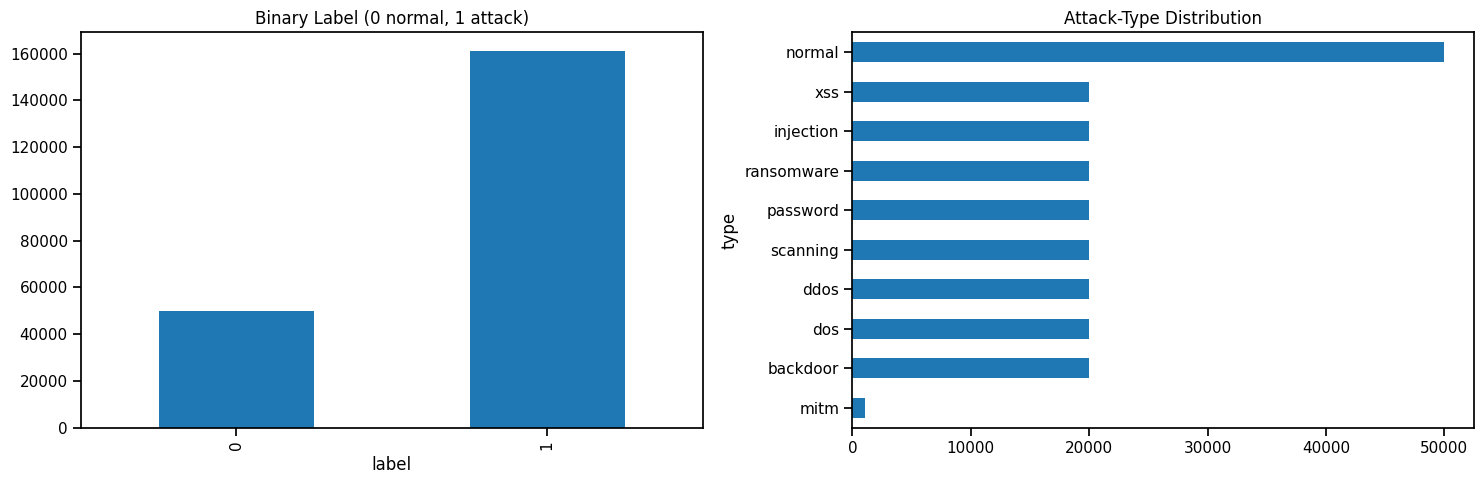

,count,pct
type,,
normal,50000,23.69
backdoor,20000,9.48
ddos,20000,9.48
dos,20000,9.48
injection,20000,9.48
password,20000,9.48
scanning,20000,9.48
ransomware,20000,9.48
xss,20000,9.48


In [7]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
net_raw.label.value_counts().sort_index().plot(kind='bar',ax=ax[0],title='Binary Label (0 normal, 1 attack)')
net_raw.type.value_counts().sort_values().plot(kind='barh',ax=ax[1],title='Attack-Type Distribution')
plt.tight_layout();plt.show()
display(pd.DataFrame({'count':net_raw.type.value_counts(),'pct':(100*net_raw.type.value_counts(normalize=True)).round(2)}))

### 6.2 Protocol, Service, Connection State, and Top Talkers

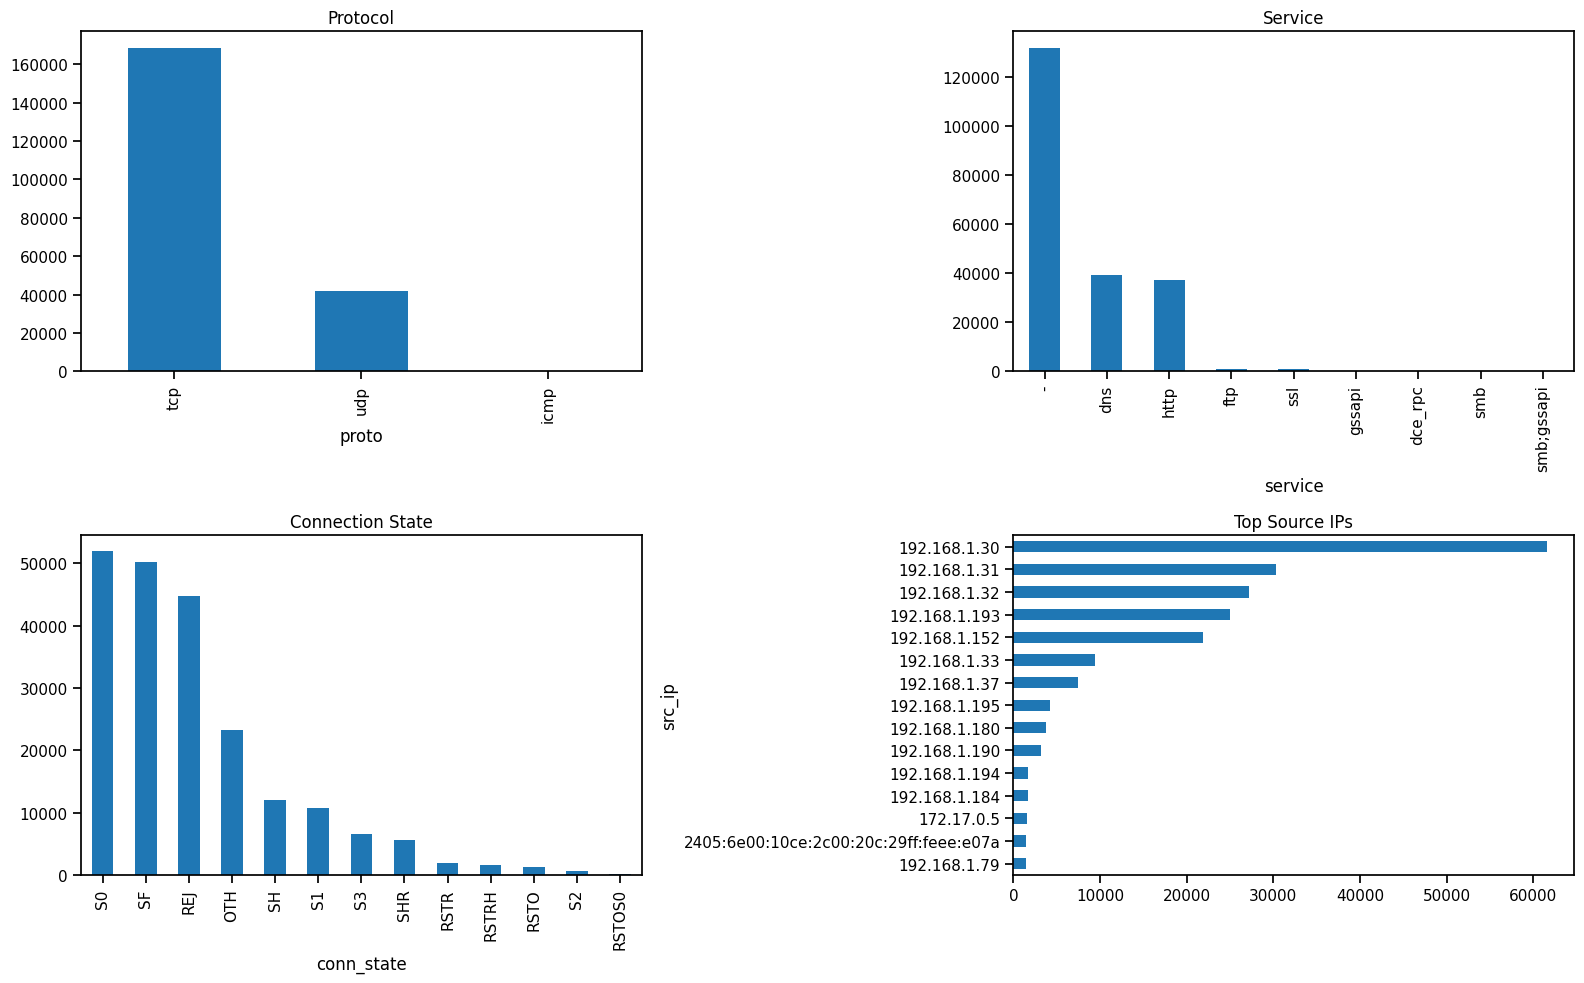

In [8]:
fig,ax=plt.subplots(2,2,figsize=(16,10))
net_raw.proto.value_counts().plot(kind='bar',ax=ax[0,0],title='Protocol')
net_raw.service.value_counts().head(12).plot(kind='bar',ax=ax[0,1],title='Service')
net_raw.conn_state.value_counts().head(15).plot(kind='bar',ax=ax[1,0],title='Connection State')
net_raw.src_ip.value_counts().head(15).sort_values().plot(kind='barh',ax=ax[1,1],title='Top Source IPs')
plt.tight_layout();plt.show()

### 6.3 Heavy-Tailed Numerical Flow Distributions

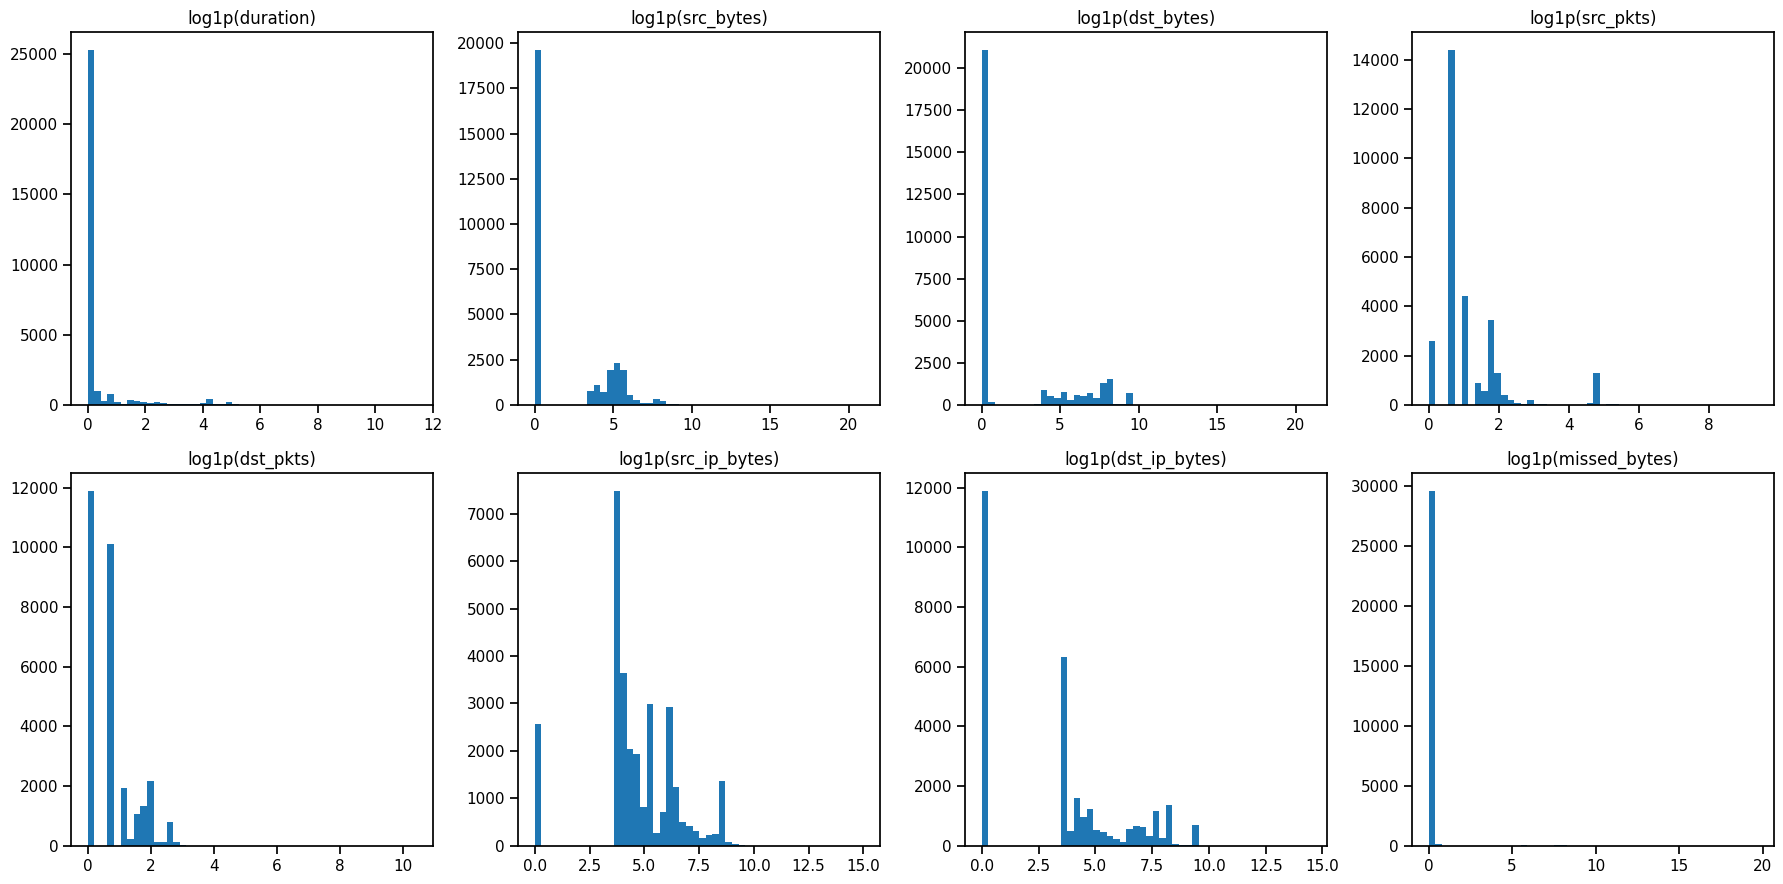

In [9]:
EDA_NUM=['duration','src_bytes','dst_bytes','src_pkts','dst_pkts','src_ip_bytes','dst_ip_bytes','missed_bytes']
eda=net_raw.sample(n=min(CFG.EDA_SAMPLE,len(net_raw)),random_state=CFG.SEED)
fig,ax=plt.subplots(2,4,figsize=(18,9))
for a,c in zip(ax.flat,EDA_NUM):
    a.hist(np.log1p(pd.to_numeric(eda[c],errors='coerce').fillna(0).clip(lower=0)),bins=50);a.set_title('log1p('+c+')')
plt.tight_layout();plt.show()

### 6.4 Class-Conditional Boxplots

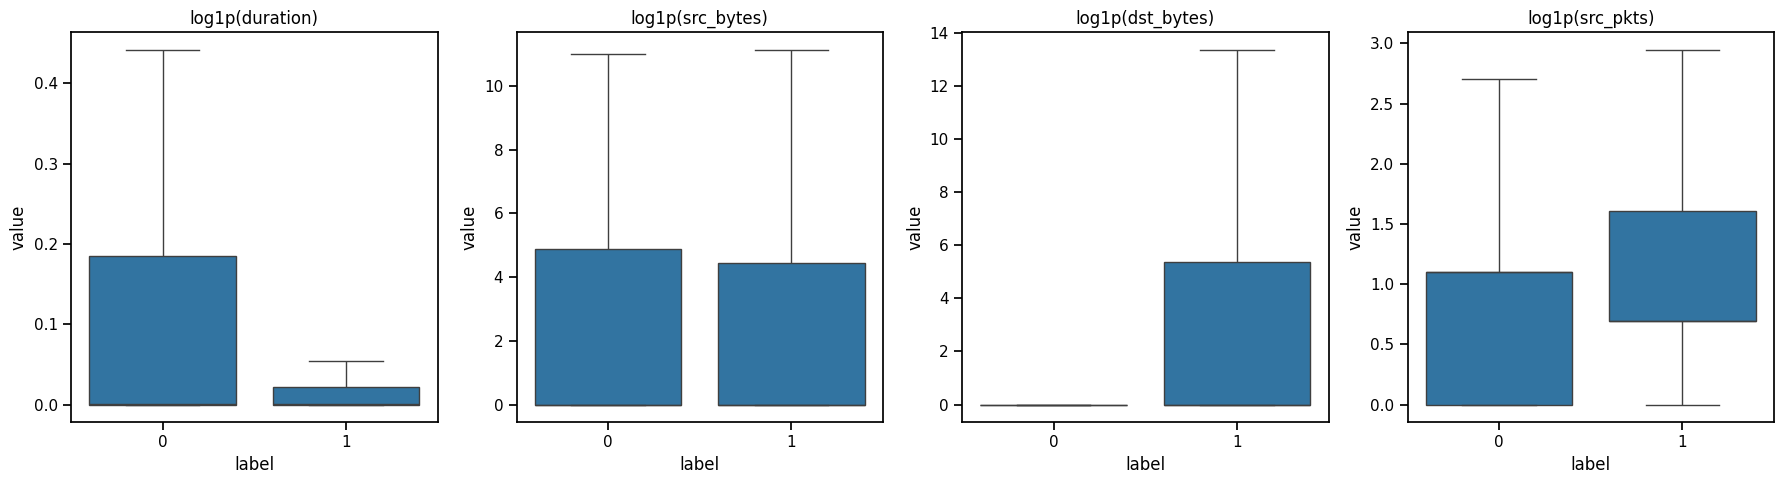

In [10]:
fig,ax=plt.subplots(1,4,figsize=(18,5))
for a,c in zip(ax,['duration','src_bytes','dst_bytes','src_pkts']):
    tmp=pd.DataFrame({'value':np.log1p(eda[c].clip(lower=0)),'label':eda.label})
    sns.boxplot(data=tmp,x='label',y='value',showfliers=False,ax=a);a.set_title('log1p('+c+')')
plt.tight_layout();plt.show()

### 6.5 PCA and t-SNE Projection
Exploratory only; these projections are not model inputs.

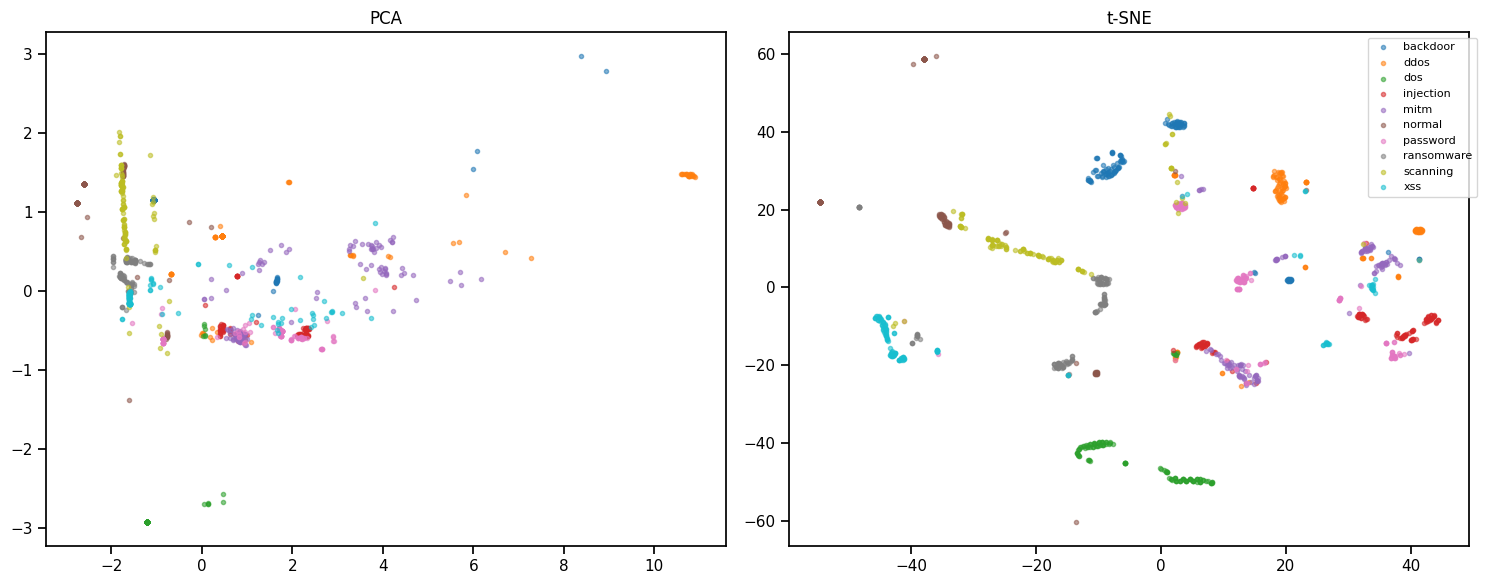

In [11]:
DIM_NUM=['src_port','dst_port','duration','src_bytes','dst_bytes','missed_bytes','src_pkts','src_ip_bytes','dst_pkts','dst_ip_bytes']
per=max(1,CFG.DIM_SAMPLE//net_raw.type.nunique())
dim_df=pd.concat([g.head(per) for _,g in net_raw.groupby('type',sort=False)],ignore_index=True).head(CFG.DIM_SAMPLE)
Xdim=dim_df[DIM_NUM].replace([np.inf,-np.inf],np.nan).fillna(0).to_numpy(float)
Xdim=StandardScaler().fit_transform(np.log1p(np.clip(Xdim,0,None)))
Xp=PCA(n_components=2,random_state=CFG.SEED).fit_transform(Xdim)
Xt=TSNE(n_components=2,random_state=CFG.SEED,init='pca',learning_rate='auto',perplexity=30).fit_transform(Xdim)
fig,ax=plt.subplots(1,2,figsize=(15,6))
for cls in dim_df.type.unique():
    m=dim_df.type.to_numpy()==cls
    ax[0].scatter(Xp[m,0],Xp[m,1],s=9,alpha=.55,label=cls);ax[1].scatter(Xt[m,0],Xt[m,1],s=9,alpha=.55,label=cls)
ax[0].set_title('PCA');ax[1].set_title('t-SNE');ax[1].legend(bbox_to_anchor=(1.02,1),fontsize=8)
plt.tight_layout();plt.show()

### 6.6 Isolation Forest Outlier Analysis
Extreme traffic is not automatically deleted because an outlier can itself be an intrusion signal.

In [12]:
iso_df=eda.head(min(10000,len(eda)));Xi=iso_df[DIM_NUM].replace([np.inf,-np.inf],np.nan).fillna(0).to_numpy(float)
Xi=StandardScaler().fit_transform(np.log1p(np.clip(Xi,0,None)))
flag=IsolationForest(contamination=.05,random_state=CFG.SEED,n_jobs=-1).fit_predict(Xi)
print('Outliers:',int((flag==-1).sum()),'/',len(flag));display(pd.crosstab(flag==-1,iso_df.label,normalize='columns').round(3))

Outliers: 500 / 10000


label,0,1
row_0,,
False,0.902,0.965
True,0.098,0.035


## 7. Statistical Analysis
This section is separate and explicit because the course requires statistics beyond model fitting.

### 7.1 Descriptive Statistics, Skewness, Kurtosis

In [13]:
desc=net_raw[EDA_NUM].describe(percentiles=[.01,.25,.5,.75,.99]).T
desc['skewness']=net_raw[EDA_NUM].skew();desc['kurtosis']=net_raw[EDA_NUM].kurtosis();display(desc.round(4))

,count,mean,std,min,1%,25%,50%,75%,99%,max,skewness,kurtosis
duration,211043.0,7.7009,5.641419e+02,0.0,0.0,0.0,0.0002,0.0542,117.9016,9.351693e+04,155.9063,25102.6420
src_bytes,211043.0,258113.5643,1.709490e+07,0.0,0.0,0.0,0.0000,130.0000,3016.0000,3.890855e+09,101.3695,15634.8168
dst_bytes,211043.0,258804.5716,1.802563e+07,0.0,0.0,0.0,0.0000,89.0000,12183.0000,3.913853e+09,113.9447,18477.0914
src_pkts,211043.0,9.5952,9.177880e+01,0.0,0.0,1.0,1.0000,4.0000,120.0000,2.462300e+04,134.7538,28778.5105
dst_pkts,211043.0,3.8469,3.307058e+02,0.0,0.0,0.0,1.0000,2.0000,12.0000,1.219420e+05,291.1248,96736.0212
src_ip_bytes,211043.0,776.0822,2.229703e+04,0.0,0.0,48.0,82.0000,415.0000,4800.0000,6.522626e+06,165.6566,39140.3025
dst_ip_bytes,211043.0,1584.6866,1.901795e+05,0.0,0.0,0.0,40.0000,134.0000,12815.0000,8.639552e+07,444.6708,201809.8497
missed_bytes,211043.0,34432.3443,5.261621e+06,0.0,0.0,0.0,0.0000,0.0000,1.0000,1.854527e+09,252.7120,79078.5491


### 7.2 D'Agostino-Pearson Normality Tests
**H₀:** sampled feature values follow a normal distribution.

In [14]:
r=[]
for c in EDA_NUM:
    x=net_raw[c].replace([np.inf,-np.inf],np.nan).dropna()
    if len(x)>CFG.NORMALITY_SAMPLE:x=x.sample(CFG.NORMALITY_SAMPLE,random_state=CFG.SEED)
    s,p=stats.normaltest(x.to_numpy(float));r.append({'feature':c,'K2':s,'p_value':p,'reject_H0':p<.05})
display(pd.DataFrame(r))

,feature,K2,p_value,reject_H0
0,duration,17815.982902,0.0,True
1,src_bytes,15403.238773,0.0,True
2,dst_bytes,15404.486959,0.0,True
3,src_pkts,14532.561015,0.0,True
4,dst_pkts,15625.350565,0.0,True
5,src_ip_bytes,15559.899134,0.0,True
6,dst_ip_bytes,14050.509302,0.0,True
7,missed_bytes,17820.997846,0.0,True


### 7.3 Mann–Whitney U: Normal vs Attack + FDR Correction
**H₀:** normal and attack observations have the same feature distribution.

In [15]:
def bh_fdr(p):
    p=np.asarray(p,float);n=len(p);order=np.argsort(p);q=p[order]*n/np.arange(1,n+1);q=np.minimum.accumulate(q[::-1])[::-1];out=np.empty(n);out[order]=np.clip(q,0,1);return out
r=[]
for c in EDA_NUM:
    a=net_raw.loc[net_raw.label==0,c].dropna().head(CFG.STAT_SAMPLE_PER_CLASS).to_numpy(float)
    b=net_raw.loc[net_raw.label==1,c].dropna().head(CFG.STAT_SAMPLE_PER_CLASS).to_numpy(float)
    U,p=mannwhitneyu(a,b,alternative='two-sided');r.append({'feature':c,'U':U,'p_value':p,'rank_biserial':1-2*U/(len(a)*len(b))})
mw=pd.DataFrame(r);mw['p_FDR']=bh_fdr(mw.p_value);mw['significant_FDR']=mw.p_FDR<.05;display(mw.sort_values('p_FDR'))

,feature,U,p_value,rank_biserial,p_FDR,significant_FDR
0,duration,26997849.0,0.000000,0.625030,0.000000,True
1,src_bytes,82270960.0,0.000000,-0.142652,0.000000,True
2,dst_bytes,80806625.0,0.000000,-0.122314,0.000000,True
3,src_pkts,33207677.0,0.000000,0.538782,0.000000,True
4,dst_pkts,17678799.0,0.000000,0.754461,0.000000,True
5,src_ip_bytes,45266072.0,0.000000,0.371305,0.000000,True
6,dst_ip_bytes,19187333.5,0.000000,0.733509,0.000000,True
7,missed_bytes,72036221.0,0.427425,-0.000503,0.427425,False


### 7.4 Kruskal–Wallis Across Attack Types
**H₀:** all attack-type groups share the same distribution for the tested feature.

In [16]:
r=[]
for c in ['duration','src_bytes','dst_bytes','src_pkts','dst_pkts']:
    groups=[g[c].dropna().head(4000).to_numpy(float) for _,g in net_raw.groupby('type',sort=False)]
    H,p=kruskal(*groups);r.append({'feature':c,'H_stat':H,'p_value':p,'reject_H0':p<.05})
display(pd.DataFrame(r))

,feature,H_stat,p_value,reject_H0
0,duration,20436.627528,0.0,True
1,src_bytes,23973.434632,0.0,True
2,dst_bytes,23204.514555,0.0,True
3,src_pkts,24059.719635,0.0,True
4,dst_pkts,23952.910214,0.0,True


### 7.5 Chi-Square: Protocol vs Binary Attack Status
**H₀:** protocol and attack status are independent.

In [17]:
ct=pd.crosstab(net_raw.proto,net_raw.label);chi,p,dof,_=chi2_contingency(ct)
print(f'chi2={chi:.3f}, dof={dof}, p={p:.3e}');print('Decision:','Reject H0' if p<.05 else 'Fail to reject H0');display(ct)

chi2=77710.088, dof=2, p=0.000e+00
Decision: Reject H0


label,0,1
proto,,
icmp,124,157
tcp,18203,150544
udp,31673,10342


### 7.6 Correlation Structure

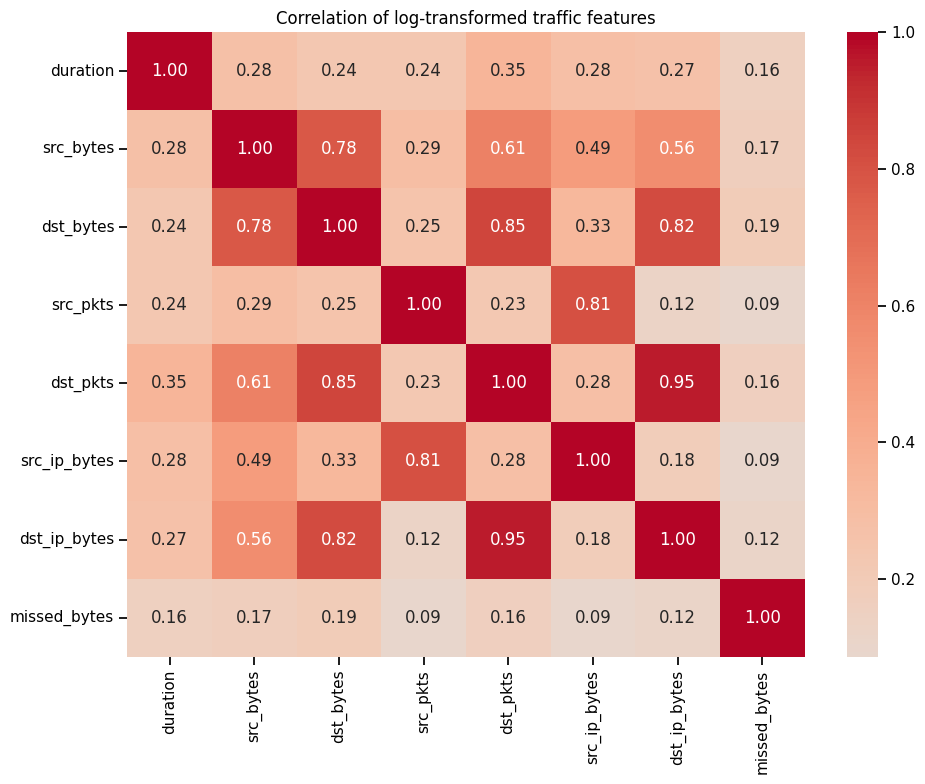

In [18]:
c=net_raw[EDA_NUM].copy()
for col in c:c[col]=np.log1p(c[col].clip(lower=0))
plt.figure(figsize=(10,8));sns.heatmap(c.corr(),annot=True,fmt='.2f',cmap='coolwarm',center=0);plt.title('Correlation of log-transformed traffic features');plt.tight_layout();plt.show()

### 7.7 Mutual Information With Binary Target
A balanced exploratory sample prevents the MI estimate from being dominated by the dataset's attack-type block ordering.

In [19]:
mi_sample=pd.concat([net_raw[net_raw.label==0].head(20000),net_raw[net_raw.label==1].head(20000)],ignore_index=True)
miX=mi_sample[DIM_NUM].replace([np.inf,-np.inf],np.nan).fillna(0)
mi=mutual_info_classif(miX,mi_sample.label,random_state=CFG.SEED)
display(pd.DataFrame({'feature':DIM_NUM,'mutual_information':mi}).sort_values('mutual_information',ascending=False))

,feature,mutual_information
9,dst_ip_bytes,0.687979
7,src_ip_bytes,0.687608
1,dst_port,0.682582
0,src_port,0.631725
8,dst_pkts,0.609528
2,duration,0.530686
6,src_pkts,0.436158
3,src_bytes,0.182876
4,dst_bytes,0.041295
5,missed_bytes,0.001201


### 7.8 Event-Order Windows, Flow Volume, Attack Rate
The processed network CSV has **no wall-clock timestamp or capture ID**, so row order is explicitly treated as event order, not as real time.

,flows,attack_rate,src_bytes,dst_bytes,flow_volume_bytes
window,,,,,
0,500,1.0,1442376,7630924,9073300
1,500,1.0,728518,4442484,5171002
2,500,1.0,508462,1224132,1732594
3,500,1.0,664366,2086080,2750446
4,500,1.0,119511,504386,623897


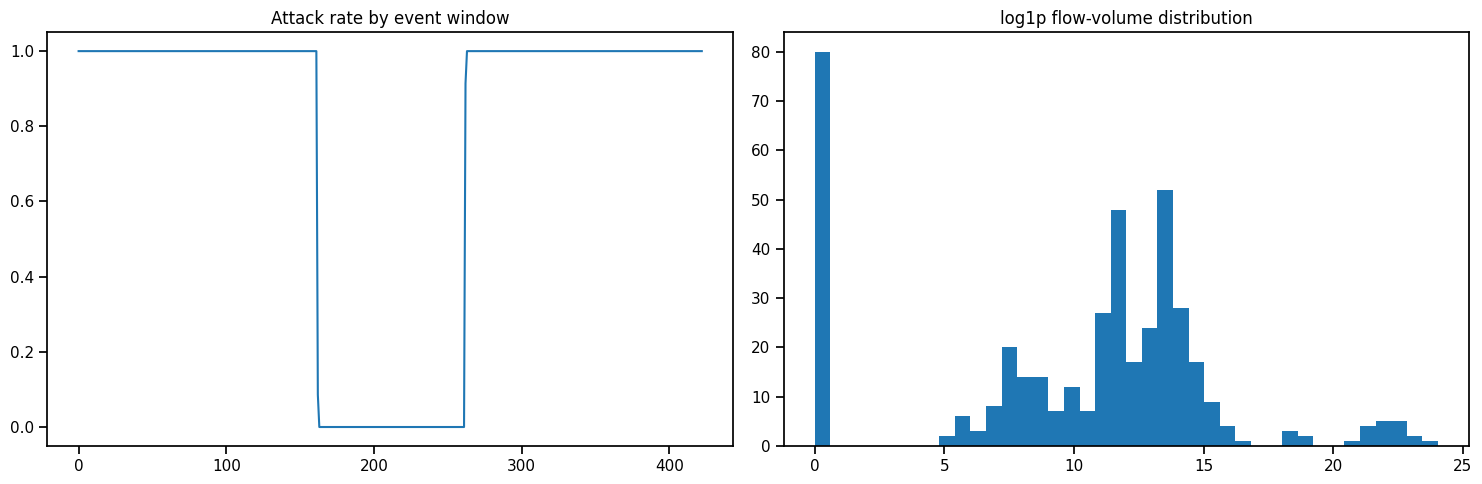

In [20]:
W=500;s=net_raw[['label','src_bytes','dst_bytes']].copy();s['window']=np.arange(len(s))//W
ws=s.groupby('window').agg(flows=('label','size'),attack_rate=('label','mean'),src_bytes=('src_bytes','sum'),dst_bytes=('dst_bytes','sum'))
ws['flow_volume_bytes']=ws.src_bytes+ws.dst_bytes;display(ws.head())
fig,ax=plt.subplots(1,2,figsize=(15,5));ax[0].plot(ws.index,ws.attack_rate);ax[0].set_title('Attack rate by event window');ax[1].hist(np.log1p(ws.flow_volume_bytes),bins=40);ax[1].set_title('log1p flow-volume distribution');plt.tight_layout();plt.show()

### 7.9 ADF + ACF/PACF on Event-Window Attack Rate
**ADF H₀:** unit root / non-stationarity.

ADF=-1.6810, p=0.4409, lags=1, nobs=421
Decision: Fail to reject unit-root H0
{'1%': np.float64(-3.445978550826048), '5%': np.float64(-2.8684297456394874), '10%': np.float64(-2.570440005247093)}


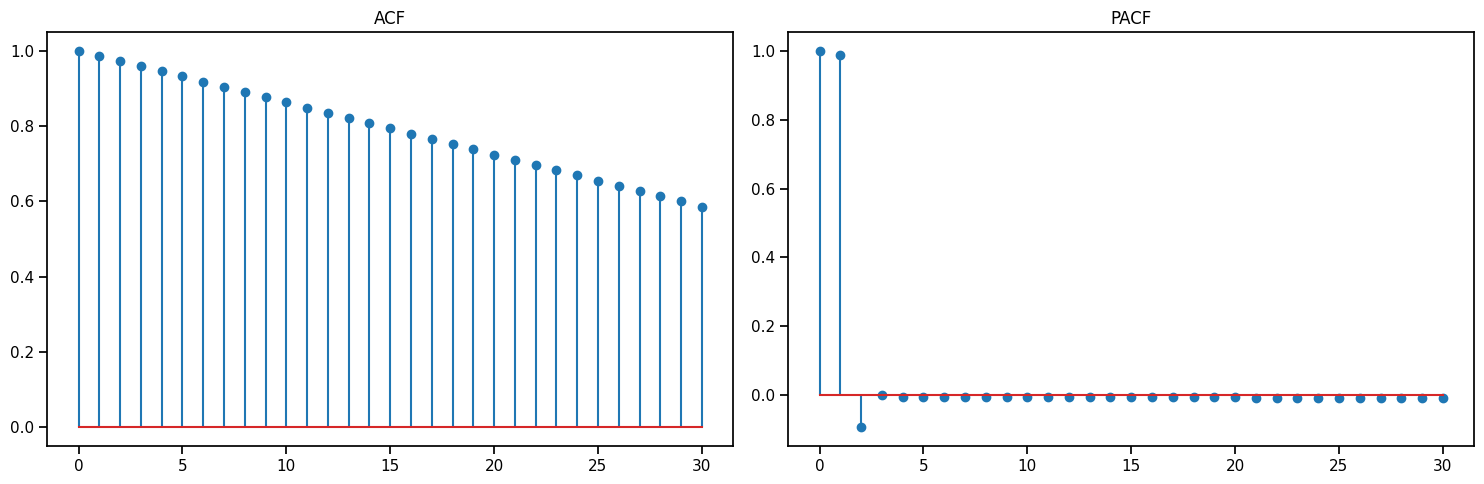

In [21]:
ser=ws.attack_rate.to_numpy(float);st,p,lag,nobs,crit,_=adfuller(ser,autolag='AIC')
print(f'ADF={st:.4f}, p={p:.4g}, lags={lag}, nobs={nobs}');print('Decision:','Reject unit-root H0' if p<.05 else 'Fail to reject unit-root H0');print(crit)
nlags=min(30,max(1,len(ser)//4));av=acf(ser,nlags=nlags,fft=True);pv=pacf(ser,nlags=min(nlags,len(ser)//2-1),method='ywm')
fig,ax=plt.subplots(1,2,figsize=(15,5));ax[0].stem(range(len(av)),av);ax[0].set_title('ACF');ax[1].stem(range(len(pv)),pv);ax[1].set_title('PACF');plt.tight_layout();plt.show()

### 7.10 True Timestamp / Inter-Arrival Analysis From IoT Telemetry
The IoT telemetry files do contain `date` and `time`, so they are used for authentic inter-arrival statistics.

Parsed telemetry rows: 261,119 | median inter-arrival(s): 1.0


,count,mean,std,min,25%,50%,75%,max
device,,,,,,,,
Fridge,39943.0,61.70,10039.21,0.0,0.0,0.0,2.0,2000696.0
GPS_Tracker,38959.0,62.01,9708.49,0.0,0.0,1.0,3.0,1907874.0
Garage_Door,39586.0,62.13,9467.70,0.0,0.0,0.0,2.0,1872801.0
Modbus,31105.0,77.77,11467.37,0.0,0.0,0.0,2.0,2014546.0
Motion_Light,39487.0,62.07,10097.50,0.0,0.0,1.0,3.0,2000541.0
Thermostat,32773.0,74.86,10414.30,0.0,0.0,1.0,2.0,1872813.0
Weather,39259.0,61.74,10197.63,0.0,0.0,0.0,2.0,2014567.0


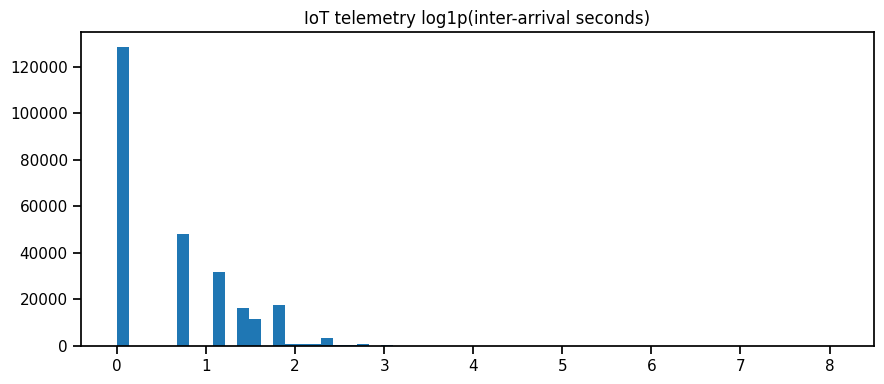

In [22]:
iot=[p for p in csv_paths if 'train_test_iot_dataset' in p.lower()];parts=[]
for p in iot:
    h=pd.read_csv(p,nrows=0)
    if {'date','time','label','type'}.issubset(h.columns):
        t=pd.read_csv(p,usecols=['date','time','label','type'],low_memory=False);t['device']=os.path.basename(p).replace('Train_Test_IoT_','').replace('.csv','')
        t['timestamp']=pd.to_datetime(t.date.astype(str).str.strip()+' '+t.time.astype(str).str.strip(),errors='coerce',dayfirst=True);parts.append(t[['device','timestamp','label','type']])
if parts:
    telemetry=pd.concat(parts,ignore_index=True).dropna(subset=['timestamp']).sort_values(['device','timestamp']);telemetry['inter_arrival_sec']=telemetry.groupby('device').timestamp.diff().dt.total_seconds()
    ia=telemetry.loc[telemetry.inter_arrival_sec.between(0,3600),'inter_arrival_sec'].dropna();print('Parsed telemetry rows:',f'{len(telemetry):,}','| median inter-arrival(s):',round(float(ia.median()),3));display(telemetry.groupby('device').inter_arrival_sec.describe().round(2))
    plt.figure(figsize=(9,4));plt.hist(np.log1p(ia),bins=60);plt.title('IoT telemetry log1p(inter-arrival seconds)');plt.tight_layout();plt.show()
else: print('Telemetry files unavailable; skipped.')

## 8. Cleaning and Row-Local Feature Engineering
Only row-local features are created before splitting; no target-based or future-window feature is used.

In [23]:
def engineer(df):
    o=df.copy();base=['src_port','dst_port','duration','src_bytes','dst_bytes','missed_bytes','src_pkts','src_ip_bytes','dst_pkts','dst_ip_bytes','http_request_body_len','http_response_body_len','http_status_code']
    for c in base:o[c]=pd.to_numeric(o[c],errors='coerce')
    o['total_bytes']=o.src_bytes+o.dst_bytes;o['total_pkts']=o.src_pkts+o.dst_pkts;o['bytes_per_pkt']=o.total_bytes/(o.total_pkts+1.)
    o['src_dst_byte_ratio']=(o.src_bytes+1)/(o.dst_bytes+1);o['src_dst_pkt_ratio']=(o.src_pkts+1)/(o.dst_pkts+1)
    o['src_privileged_port']=(o.src_port<1024).astype(int);o['dst_privileged_port']=(o.dst_port<1024).astype(int)
    for c in ['src_bytes','dst_bytes','total_bytes','src_pkts','dst_pkts','total_pkts','duration','missed_bytes','src_ip_bytes','dst_ip_bytes']:
        o['log1p_'+c]=np.log1p(np.clip(o[c].astype(float),0,None))
    return o.replace([np.inf,-np.inf],np.nan)
net=engineer(net_raw);print('Engineered shape:',net.shape)

Engineered shape: (211043, 62)


## 9. Leakage-Aware Split
A random flow split is deliberately avoided. Because the merged CSV has no capture/session ID, we use **ordered-within-scenario 60/20/20**: first 60% of each `type` → train, next 20% → validation, final 20% → test. This preserves class coverage and row order, while transparently acknowledging that a true capture-wise split would be stronger.

In [24]:
def ordered_split(df):
    tr=[];va=[];te=[]
    for _,g in df.groupby('type',sort=False):
        idx=g.index.to_numpy();a=int(.6*len(idx));b=int(.8*len(idx));tr+=idx[:a].tolist();va+=idx[a:b].tolist();te+=idx[b:].tolist()
    return df.loc[sorted(tr)].reset_index(drop=True),df.loc[sorted(va)].reset_index(drop=True),df.loc[sorted(te)].reset_index(drop=True)
train_df,val_df,test_df=ordered_split(net)
print('Shapes:',train_df.shape,val_df.shape,test_df.shape)
display(pd.concat({'train':train_df.type.value_counts(),'validation':val_df.type.value_counts(),'test':test_df.type.value_counts()},axis=1).fillna(0).astype(int))
assert set(train_df._row_id).isdisjoint(val_df._row_id) and set(train_df._row_id).isdisjoint(test_df._row_id) and set(val_df._row_id).isdisjoint(test_df._row_id)
print('Split overlap check: PASSED')

Shapes: (126625, 62) (42209, 62) (42209, 62)


,train,validation,test
type,,,
normal,30000,10000,10000
backdoor,12000,4000,4000
ddos,12000,4000,4000
dos,12000,4000,4000
injection,12000,4000,4000
password,12000,4000,4000
scanning,12000,4000,4000
ransomware,12000,4000,4000
xss,12000,4000,4000


Split overlap check: PASSED


### 9.1 Deterministic Proportional Runtime Caps

In [25]:
def cap(df,n):
    if n is None or len(df)<=n:return df.copy().reset_index(drop=True)
    counts=df.type.value_counts();raw=counts/counts.sum()*n;q=np.floor(raw).astype(int).clip(lower=1)
    while q.sum()<n:
        for c in (raw-np.floor(raw)).sort_values(ascending=False).index:
            if q.sum()>=n:break
            if q[c]<counts[c]:q[c]+=1
    while q.sum()>n:
        for c in q.sort_values(ascending=False).index:
            if q.sum()<=n:break
            if q[c]>1:q[c]-=1
    return pd.concat([df[df.type==c].head(int(k)) for c,k in q.items()]).sort_values('_row_id').reset_index(drop=True)
base_tr=cap(train_df,CFG.BASELINE_TRAIN_MAX);base_va=cap(val_df,CFG.BASELINE_VAL_MAX)
graph_tr=cap(train_df,CFG.GRAPH_TRAIN_MAX);graph_va=cap(val_df,CFG.GRAPH_VAL_MAX);graph_te=cap(test_df,CFG.GRAPH_TEST_MAX)
print('Baseline train/val:',len(base_tr),len(base_va));print('Graph train/val/test:',len(graph_tr),len(graph_va),len(graph_te))

Baseline train/val: 70000 22000
Graph train/val/test: 40000 12000 12000


## 10. Train-Only Preprocessing and Edge Features
IP identities are reserved for topology rather than fed as tabular predictors.

In [26]:
NUM=['src_port','dst_port','duration','src_bytes','dst_bytes','missed_bytes','src_pkts','src_ip_bytes','dst_pkts','dst_ip_bytes','http_request_body_len','http_response_body_len','http_status_code','total_bytes','total_pkts','bytes_per_pkt','src_dst_byte_ratio','src_dst_pkt_ratio','src_privileged_port','dst_privileged_port','log1p_src_bytes','log1p_dst_bytes','log1p_total_bytes','log1p_total_pkts','log1p_duration']
CAT=['proto','service','conn_state'];FEATS=NUM+CAT
try:ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
except TypeError:ohe=OneHotEncoder(handle_unknown='ignore',sparse=False)
prep=ColumnTransformer([('num',Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]),NUM),('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('ohe',ohe)]),CAT)],sparse_threshold=0.)
le=LabelEncoder().fit(train_df.type);print('Classes:',list(le.classes_))

Classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


In [27]:
t0=time.time();Xbtr=prep.fit_transform(base_tr[FEATS]).astype('float32');Xbva=prep.transform(base_va[FEATS]).astype('float32');Xgtr=prep.transform(graph_tr[FEATS]).astype('float32');Xgva=prep.transform(graph_va[FEATS]).astype('float32');Xgte=prep.transform(graph_te[FEATS]).astype('float32')
ybtr=le.transform(base_tr.type);ybva=le.transform(base_va.type);ygtr=le.transform(graph_tr.type);ygva=le.transform(graph_va.type);ygte=le.transform(graph_te.type)
feature_names=prep.get_feature_names_out();print('Feature count:',len(feature_names),'| prep seconds:',round(time.time()-t0,2));print(Xgtr.shape,Xgva.shape,Xgte.shape)

Feature count: 50 | prep seconds: 0.46
(40000, 50) (12000, 50) (12000, 50)


## 11. Class Imbalance Strategy
Class weights are preferred to SMOTE/edge duplication because synthetic or duplicated edges can distort graph topology.

In [28]:
ids=np.arange(len(le.classes_));cw=compute_class_weight('balanced',classes=ids,y=ybtr);display(pd.DataFrame({'class_id':ids,'class_name':le.classes_,'weight':cw}))

,class_id,class_name,weight
0,0,backdoor,1.055170
1,1,ddos,1.055170
2,2,dos,1.055170
3,3,injection,1.055170
4,4,mitm,20.289855
5,5,normal,0.422094
6,6,password,1.055170
7,7,ransomware,1.055329
8,8,scanning,1.055170
9,9,xss,1.055170


## 12. Unified Evaluation Helper
Main metrics: multiclass accuracy, macro precision/recall/F1, weighted F1; operational binary metrics: ROC-AUC, PR-AUC, FPR.

In [29]:
NORMAL_ID=int(np.where(le.classes_=='normal')[0][0])
def size_mb(m):
    try:return len(pickle.dumps(m))/(1024**2)
    except:return np.nan
def evaluate(y,pred,prob,train_s=np.nan,model_mb=np.nan):
    y=np.asarray(y);pred=np.asarray(pred);yb=(y!=NORMAL_ID).astype(int);pb=(pred!=NORMAL_ID).astype(int);ap=1-prob[:,NORMAL_ID];tn,fp,fn,tp=confusion_matrix(yb,pb,labels=[0,1]).ravel()
    return {'Accuracy':accuracy_score(y,pred),'Macro Precision':precision_score(y,pred,average='macro',zero_division=0),'Macro Recall':recall_score(y,pred,average='macro',zero_division=0),'Macro F1':f1_score(y,pred,average='macro',zero_division=0),'Weighted F1':f1_score(y,pred,average='weighted',zero_division=0),'Binary ROC-AUC':roc_auc_score(yb,ap),'Binary PR-AUC':average_precision_score(yb,ap),'False Positive Rate':fp/max(fp+tn,1),'Train Time (s)':train_s,'Model Size (MB)':model_mb,'_pred':pred,'_proba':prob,'_y':y}
results={}

## 13. Track A — Logistic Regression Baseline

In [30]:
lr=LogisticRegression(max_iter=500,class_weight='balanced',solver='lbfgs',random_state=CFG.SEED);t0=time.time();lr.fit(Xbtr,ybtr);dt=time.time()-t0
pred=lr.predict(Xgte);prob=lr.predict_proba(Xgte);results['Logistic Regression']=evaluate(ygte,pred,prob,dt,size_mb(lr));print({k:round(v,4) for k,v in results['Logistic Regression'].items() if not k.startswith('_')})

{'Accuracy': 0.6573, 'Macro Precision': 0.7147, 'Macro Recall': 0.764, 'Macro F1': 0.6552, 'Weighted F1': 0.6224, 'Binary ROC-AUC': np.float64(0.2917), 'Binary PR-AUC': np.float64(0.7275), 'False Positive Rate': np.float64(0.943), 'Train Time (s)': 28.562, 'Model Size (MB)': 0.0046}


### 13.1 Additional Classical Baselines
To make Track A a meaningful benchmark rather than a single-model comparison, four additional models are included. All use the **same leakage-aware training/test partitions** as the other edge-level models.

| Model | Why include it? |
|---|---|
| Decision Tree | Very interpretable non-linear baseline and useful viva reference point. |
| Gaussian Naive Bayes | Simple probabilistic baseline with strong independence assumptions. |
| SGD Logistic | Fast scalable linear classifier; tests whether a simple linear decision surface is sufficient. |
| Dummy Most-Frequent | Sanity-check baseline showing performance without learning useful structure. |

The objective is not to claim that every baseline is optimal; it is to show how much improvement is attributable to ensemble learning and graph structure.

In [31]:
additional_baselines = {
    'Dummy Most-Frequent': DummyClassifier(strategy='most_frequent'),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=24, min_samples_leaf=2, class_weight='balanced', random_state=CFG.SEED),
    'Gaussian Naive Bayes': GaussianNB(var_smoothing=1e-8),
    'SGD Log-Loss': SGDClassifier(
        loss='log_loss', alpha=1e-4, max_iter=1200, tol=1e-3,
        class_weight='balanced', random_state=CFG.SEED)
}

for name, clf in additional_baselines.items():
    t0 = time.time(); clf.fit(Xbtr, ybtr); train_s = time.time() - t0
    pred = clf.predict(Xgte); prob = clf.predict_proba(Xgte)
    results[name] = evaluate(ygte, pred, prob, train_s, size_mb(clf))
    print(name, {k: round(v,4) for k,v in results[name].items() if not k.startswith('_')})

Dummy Most-Frequent {'Accuracy': 0.2369, 'Macro Precision': 0.0237, 'Macro Recall': 0.1, 'Macro F1': 0.0383, 'Weighted F1': 0.0908, 'Binary ROC-AUC': np.float64(0.5), 'Binary PR-AUC': np.float64(0.7631), 'False Positive Rate': np.float64(0.0), 'Train Time (s)': 0.0029, 'Model Size (MB)': 0.0006}
Decision Tree {'Accuracy': 0.862, 'Macro Precision': 0.7974, 'Macro Recall': 0.7979, 'Macro F1': 0.7793, 'Weighted F1': 0.8487, 'Binary ROC-AUC': np.float64(0.9713), 'Binary PR-AUC': np.float64(0.9829), 'False Positive Rate': np.float64(0.0552), 'Train Time (s)': 0.5355, 'Model Size (MB)': 0.1573}
Gaussian Naive Bayes {'Accuracy': 0.5976, 'Macro Precision': 0.5636, 'Macro Recall': 0.5809, 'Macro F1': 0.4866, 'Weighted F1': 0.5831, 'Binary ROC-AUC': np.float64(0.9754), 'Binary PR-AUC': np.float64(0.985), 'False Positive Rate': np.float64(0.0999), 'Train Time (s)': 0.0328, 'Model Size (MB)': 0.0084}
SGD Log-Loss {'Accuracy': 0.5823, 'Macro Precision': 0.6269, 'Macro Recall': 0.6848, 'Macro F1': 0

## 14. Track A — Random Forest Tuning on Validation Data
The test split is not used for hyperparameter selection.

In [32]:
candidates=[{'n_estimators':120,'max_depth':None,'min_samples_leaf':1,'max_features':'sqrt'},{'n_estimators':160,'max_depth':24,'min_samples_leaf':1,'max_features':'sqrt'},{'n_estimators':160,'max_depth':18,'min_samples_leaf':2,'max_features':.7}]
trials=[]
for i,p in enumerate(candidates,1):
    m=RandomForestClassifier(**p,class_weight='balanced_subsample',n_jobs=-1,random_state=CFG.SEED);t0=time.time();m.fit(Xbtr,ybtr);dt=time.time()-t0;vp=m.predict(Xbva);trials.append({'trial':i,**p,'val_macro_f1':f1_score(ybva,vp,average='macro',zero_division=0),'train_s':dt})
trials=pd.DataFrame(trials).sort_values('val_macro_f1',ascending=False);display(trials);best=candidates[int(trials.iloc[0].trial)-1];print('Selected:',best)

,trial,n_estimators,max_depth,min_samples_leaf,max_features,val_macro_f1,train_s
1,2,160,24.0,1,sqrt,0.867138,5.549348
0,1,120,NaN,1,sqrt,0.861816,4.234597
2,3,160,18.0,2,0.7,0.830815,15.415848


Selected: {'n_estimators': 160, 'max_depth': 24, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [33]:
rf=RandomForestClassifier(**best,class_weight='balanced_subsample',n_jobs=-1,random_state=CFG.SEED);t0=time.time();rf.fit(Xbtr,ybtr);dt=time.time()-t0
pred=rf.predict(Xgte);prob=rf.predict_proba(Xgte);results['Random Forest']=evaluate(ygte,pred,prob,dt,size_mb(rf));print({k:round(v,4) for k,v in results['Random Forest'].items() if not k.startswith('_')})

{'Accuracy': 0.9531, 'Macro Precision': 0.9182, 'Macro Recall': 0.8909, 'Macro F1': 0.8995, 'Weighted F1': 0.9508, 'Binary ROC-AUC': np.float64(0.9957), 'Binary PR-AUC': np.float64(0.9988), 'False Positive Rate': np.float64(0.0134), 'Train Time (s)': 5.6842, 'Model Size (MB)': 33.3566}


### 14.1 Extra Trees Additional Benchmark

In [34]:
et=ExtraTreesClassifier(n_estimators=160,max_features='sqrt',class_weight='balanced',n_jobs=-1,random_state=CFG.SEED);t0=time.time();et.fit(Xbtr,ybtr);dt=time.time()-t0
pred=et.predict(Xgte);prob=et.predict_proba(Xgte);results['Extra Trees']=evaluate(ygte,pred,prob,dt,size_mb(et));print({k:round(v,4) for k,v in results['Extra Trees'].items() if not k.startswith('_')})

{'Accuracy': 0.8855, 'Macro Precision': 0.8777, 'Macro Recall': 0.8603, 'Macro F1': 0.8557, 'Weighted F1': 0.8877, 'Binary ROC-AUC': np.float64(0.9922), 'Binary PR-AUC': np.float64(0.9978), 'False Positive Rate': np.float64(0.3057), 'Train Time (s)': 3.0395, 'Model Size (MB)': 74.3486}


### 14.2 Random Forest Feature Importance

,feature,importance
7,num__src_ip_bytes,0.100376
1,num__dst_port,0.094925
0,num__src_port,0.068720
23,num__log1p_total_pkts,0.048678
9,num__dst_ip_bytes,0.047585
14,num__total_pkts,0.044377
24,num__log1p_duration,0.042605
18,num__src_privileged_port,0.040587
3,num__src_bytes,0.039384
2,num__duration,0.034460


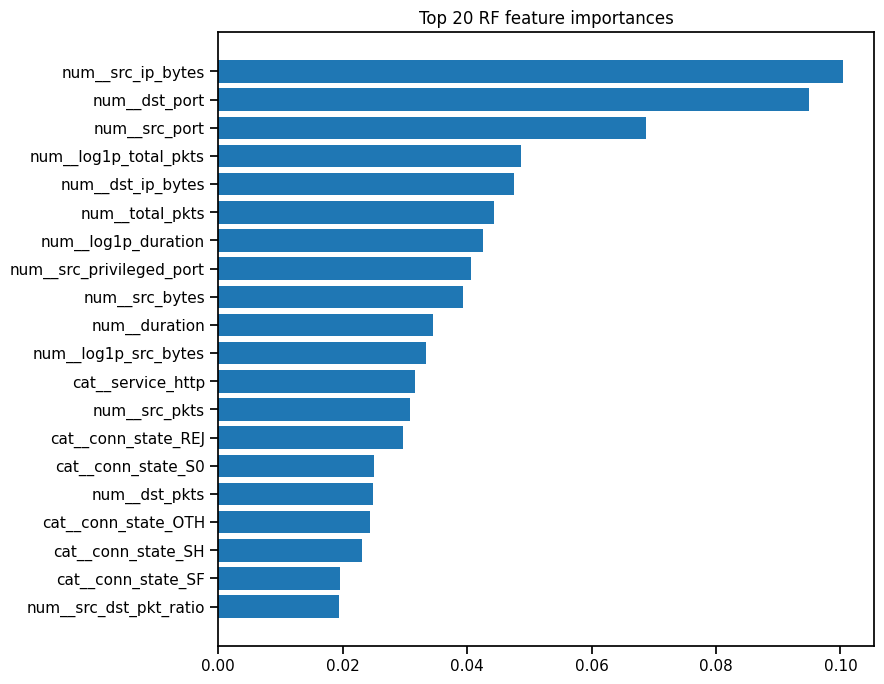

In [35]:
imp=pd.DataFrame({'feature':feature_names,'importance':rf.feature_importances_}).sort_values('importance',ascending=False).head(20);display(imp)
plt.figure(figsize=(9,7));plt.barh(imp.feature[::-1],imp.importance[::-1]);plt.title('Top 20 RF feature importances');plt.tight_layout();plt.show()

## 15. Temporal/Event-Window Aggregate Baseline
Fixed-count event windows are used because the network CSV has no timestamp. This is supplemental because its prediction unit is a window, not an individual flow edge.

In [36]:
AGG=['duration','src_bytes','dst_bytes','src_pkts','dst_pkts','total_bytes','total_pkts']
def window_ds(df,w):
    out=[];d=df.sort_values('_row_id').reset_index(drop=True)
    for st in range(0,len(d),w):
        x=d.iloc[st:st+w]
        if len(x)<max(50,w//4):continue
        r={'window_n':len(x),'unique_src':x.src_ip.nunique(),'unique_dst':x.dst_ip.nunique(),'unique_service':x.service.nunique(),'target_type':x.type.mode().iloc[0]}
        for c in AGG:r[c+'_mean']=x[c].mean();r[c+'_std']=x[c].std();r[c+'_max']=x[c].max()
        out.append(r)
    return pd.DataFrame(out)
atr=window_ds(train_df,CFG.AGG_WINDOW);ate=window_ds(test_df,CFG.AGG_WINDOW);af=[c for c in atr if c!='target_type'];ale=LabelEncoder().fit(atr.target_type)
am=RandomForestClassifier(n_estimators=200,class_weight='balanced_subsample',n_jobs=-1,random_state=CFG.SEED).fit(atr[af].fillna(0),ale.transform(atr.target_type));ap=am.predict(ate[af].fillna(0));ay=ale.transform(ate.target_type)
print('Window accuracy:',round(accuracy_score(ay,ap),4),'| macro-F1:',round(f1_score(ay,ap,average='macro',zero_division=0),4),'| windows:',len(atr),len(ate))

Window accuracy: 0.7176 | macro-F1: 0.7389 | windows: 254 85


## 16. Graph Formulation
For each event window, construct directed \(G_t=(V_t,E_t)\):
- nodes = unique source/destination IP hosts,
- directed flow edges = `src_ip → dst_ip`,
- edge features = train-fitted flow features,
- edge labels = multiclass `type`,
- node features = log out-degree, log in-degree, mean incident edge features,
- message-passing adjacency includes reverse edges while original flow direction is retained for classification,
- temporal snapshots = fixed-count event windows of `SNAPSHOT_EDGES` flows.

**Why GraphSAGE:** inductive neighbour aggregation does not require a permanent learned embedding for every host.

In [37]:
def build_snaps(df,X,y,w):
    out=[]
    for st in range(0,len(df),w):
        sub=df.iloc[st:st+w]
        if len(sub)==0:continue
        ea=torch.tensor(X[st:st+w],dtype=torch.float32);yy=torch.tensor(y[st:st+w],dtype=torch.long);sv=sub.src_ip.astype(str).tolist();dv=sub.dst_ip.astype(str).tolist();nodes=pd.Index(pd.unique(np.asarray(sv+dv,dtype=object)));mp={n:i for i,n in enumerate(nodes)}
        src=torch.tensor([mp[v] for v in sv],dtype=torch.long);dst=torch.tensor([mp[v] for v in dv],dtype=torch.long);n=len(nodes);f=ea.shape[1];sm=torch.zeros((n,f));ct=torch.zeros((n,1));one=torch.ones((len(src),1));sm.index_add_(0,src,ea);sm.index_add_(0,dst,ea);ct.index_add_(0,src,one);ct.index_add_(0,dst,one);mean=sm/ct.clamp_min(1);od=torch.zeros((n,1));idg=torch.zeros((n,1));od.index_add_(0,src,one);idg.index_add_(0,dst,one);nxv=torch.cat([torch.log1p(od),torch.log1p(idg),mean],1);ei=torch.stack([torch.cat([src,dst]),torch.cat([dst,src])])
        out.append({'node_x':nxv,'edge_index':ei,'flow_src':src,'flow_dst':dst,'edge_attr':ea,'y':yy,'row_ids':sub._row_id.to_numpy(),'node_names':nodes.to_numpy()})
    return out
trS=build_snaps(graph_tr,Xgtr,ygtr,CFG.SNAPSHOT_EDGES);vaS=build_snaps(graph_va,Xgva,ygva,CFG.SNAPSHOT_EDGES);teS=build_snaps(graph_te,Xgte,ygte,CFG.SNAPSHOT_EDGES)
print('Snapshots:',len(trS),len(vaS),len(teS));print('node_x',tuple(trS[0]['node_x'].shape),'edge_index',tuple(trS[0]['edge_index'].shape),'edge_attr',tuple(trS[0]['edge_attr'].shape),'y',tuple(trS[0]['y'].shape))

Snapshots: 16 5 5
node_x (5, 52) edge_index (2, 5000) edge_attr (2500, 50) y (2500,)


### 16.0 Graph-Construction Audit: Does `edge_index` Really Match `src_ip → dst_ip`?
This audit is intentionally explicit because **graph connectivity is the main focus**. `flow_src` and `flow_dst` store the original directed flow endpoints used for edge classification. `edge_index` contains both the original and reverse directions for message passing, so information can propagate in both directions without losing the true flow direction.

In [38]:
s0=trS[0];n_show=min(12,len(s0['y']))
audit_rows=[]
for j in range(n_show):
    src_idx=int(s0['flow_src'][j]);dst_idx=int(s0['flow_dst'][j])
    original=graph_tr.iloc[j]
    audit_rows.append({
        'edge_row':j,'row_id':int(original._row_id),
        'csv_src_ip':str(original.src_ip),'mapped_src_ip':str(s0['node_names'][src_idx]),'src_node_index':src_idx,
        'csv_dst_ip':str(original.dst_ip),'mapped_dst_ip':str(s0['node_names'][dst_idx]),'dst_node_index':dst_idx,
        'attack_type':str(original.type),'src_match':str(original.src_ip)==str(s0['node_names'][src_idx]),
        'dst_match':str(original.dst_ip)==str(s0['node_names'][dst_idx])})
audit_df=pd.DataFrame(audit_rows);display(audit_df)
print('All displayed source mappings correct:',audit_df.src_match.all())
print('All displayed destination mappings correct:',audit_df.dst_match.all())
print('Original flow edges in snapshot:',len(s0['flow_src']))
print('Message-passing edges (forward + reverse):',s0['edge_index'].shape[1])
print('First 8 message-passing index pairs:')
print(s0['edge_index'][:,:8].T.cpu().numpy())

,edge_row,row_id,csv_src_ip,mapped_src_ip,src_node_index,csv_dst_ip,mapped_dst_ip,dst_node_index,attack_type,src_match,dst_match
0,0,0,192.168.1.37,192.168.1.37,0,192.168.1.193,192.168.1.193,1,backdoor,True,True
1,1,1,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
2,2,2,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
3,3,3,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
4,4,4,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
5,5,5,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
6,6,6,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
7,7,7,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
8,8,8,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True
9,9,9,192.168.1.193,192.168.1.193,1,192.168.1.37,192.168.1.37,0,backdoor,True,True


All displayed source mappings correct: True
All displayed destination mappings correct: True
Original flow edges in snapshot: 2500
Message-passing edges (forward + reverse): 5000
First 8 message-passing index pairs:
[[0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


### 16.1 Window-Size Sensitivity Diagnostics

In [39]:
def diag(df,windows=(1000,2500,5000)):
    r=[]
    for w in windows:
        ns=[];es=[];dens=[]
        for st in range(0,min(len(df),20000),w):
            x=df.iloc[st:st+w];n=len(pd.unique(pd.concat([x.src_ip,x.dst_ip],ignore_index=True)));e=len(x);ns.append(n);es.append(e);dens.append(e/max(n*(n-1),1))
        r.append({'window_edges':w,'snapshots_checked':len(ns),'mean_nodes':np.mean(ns),'mean_edges':np.mean(es),'mean_directed_density':np.mean(dens)})
    return pd.DataFrame(r)
display(diag(graph_tr))

,window_edges,snapshots_checked,mean_nodes,mean_edges,mean_directed_density
0,1000,20,13.550,1000.0,27.587002
1,2500,8,20.125,2500.0,31.976857
2,5000,4,32.250,5000.0,17.156125


### 16.2 Graph Connection Table — The Core Network Object
The central object in this project is not merely a collection of rows. Each flow creates a directed connection
\(u \rightarrow v\) from `src_ip` to `dst_ip`. Repeated flows between the same host pair are aggregated only for **visualisation and topology analysis**; the GNN still receives individual flow edges.

For each directed host pair we compute:
- number of flow edges,
- attack rate,
- total transferred bytes,
- dominant attack type,
- dominant protocol and service.

This table provides a transparent bridge between the raw CSV and the graph shown in the figures below.

In [40]:
graph_view = graph_tr.head(min(CFG.GRAPH_VIEW_ROWS, len(graph_tr))).copy()
connection_table = (graph_view.groupby(['src_ip','dst_ip'], as_index=False)
    .agg(flow_count=('label','size'),
         attack_rate=('label','mean'),
         total_bytes_sum=('total_bytes','sum'),
         dominant_attack=('type', lambda s: s.value_counts().index[0]),
         dominant_proto=('proto', lambda s: s.value_counts().index[0]),
         dominant_service=('service', lambda s: s.value_counts().index[0])))
connection_table['log_flow_count'] = np.log1p(connection_table['flow_count'])
connection_table = connection_table.sort_values(['flow_count','attack_rate'], ascending=False).reset_index(drop=True)
print('Flow rows represented:', len(graph_view))
print('Unique directed host pairs:', len(connection_table))
display(connection_table.head(20))

Flow rows represented: 30000
Unique directed host pairs: 186


,src_ip,dst_ip,flow_count,attack_rate,total_bytes_sum,dominant_attack,dominant_proto,dominant_service,log_flow_count
0,192.168.1.152,192.168.1.152,6365,0.000000,353,normal,tcp,-,8.758727
1,192.168.1.30,192.168.1.184,4316,1.000000,27290078464,ddos,tcp,-,8.370316
2,192.168.1.193,192.168.1.37,2480,1.000000,6821770,backdoor,tcp,-,7.816417
3,192.168.1.30,192.168.1.190,1605,1.000000,1299583,dos,tcp,-,7.381502
4,192.168.1.31,192.168.1.195,1480,1.000000,2104044,injection,tcp,http,7.300473
5,192.168.1.79,192.168.1.255,1391,0.000000,0,normal,udp,-,7.238497
6,192.168.1.193,192.168.1.33,1269,1.000000,11555147,backdoor,tcp,-,7.146772
7,192.168.1.31,192.168.1.190,1182,1.000000,2335708,password,tcp,http,7.075809
8,192.168.1.152,192.168.1.190,1174,0.000000,362081,normal,udp,dns,7.069023
9,192.168.1.30,192.168.1.152,1010,0.960396,388947,dos,tcp,-,6.918695


### 16.3 Weighted Directed Host-to-Host Graph
This is the main **connection view**. A node is a host/IP. An arrow is an observed source-to-destination relationship. Edge thickness represents repeated communication frequency, while attack-dominant connections are highlighted separately from mostly-normal connections.

Unlike a simple `DiGraph` created row-by-row, this view does **not silently overwrite repeated flows**. Repeated flows are first aggregated into the `flow_count` edge weight.

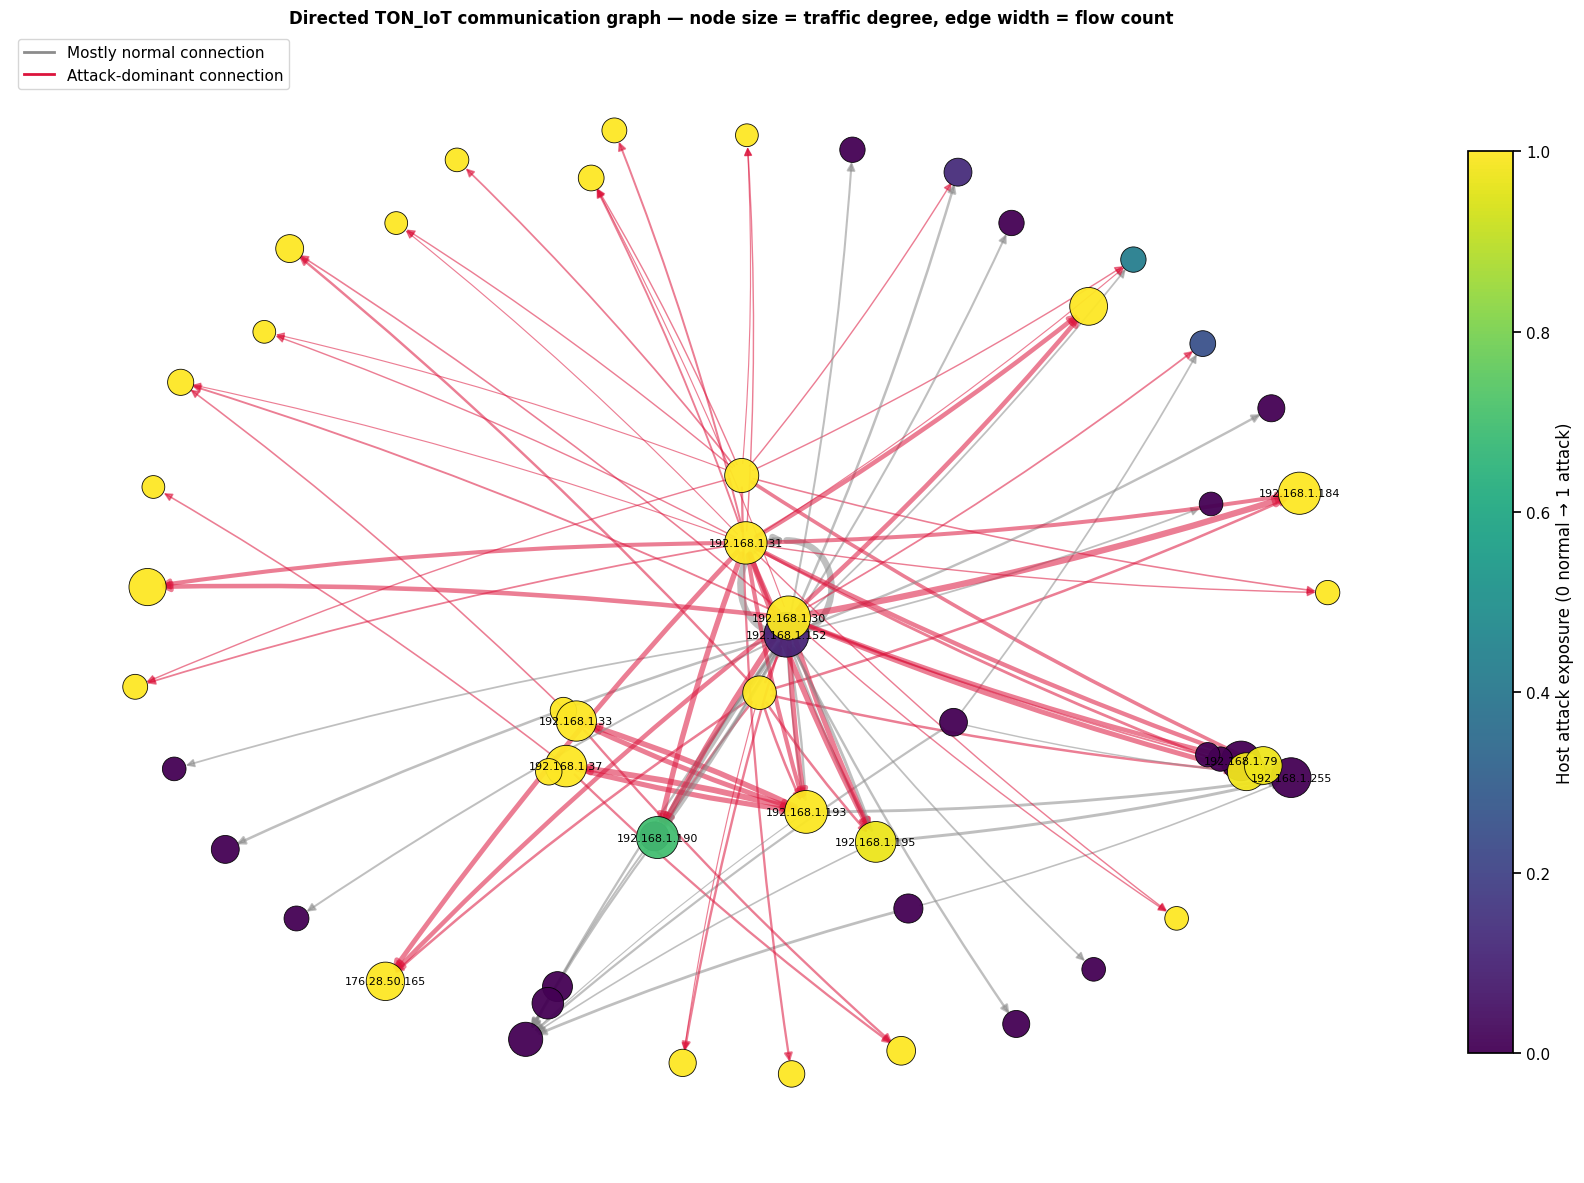

Displayed graph nodes: 55 | displayed directed pairs: 109


In [41]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

GA = nx.DiGraph()
for r in connection_table.itertuples(index=False):
    GA.add_edge(str(r.src_ip), str(r.dst_ip),
                flow_count=int(r.flow_count), attack_rate=float(r.attack_rate),
                dominant_attack=str(r.dominant_attack), total_bytes=float(r.total_bytes_sum))

weighted_degree = dict(GA.degree(weight='flow_count'))
top_hosts = [n for n,_ in sorted(weighted_degree.items(), key=lambda kv: kv[1], reverse=True)[:CFG.GRAPH_VIEW_TOP_NODES]]
H = GA.subgraph(top_hosts).copy()

# Keep only connections among high-activity hosts for a readable paper-style figure.
pos = nx.spring_layout(H, seed=CFG.SEED, k=1.15/np.sqrt(max(H.number_of_nodes(),1)), iterations=120)
node_flow = np.array([weighted_degree.get(n,1) for n in H.nodes()], dtype=float)
node_sizes = 140 + 900*(np.log1p(node_flow)/max(np.log1p(node_flow).max(),1e-9))

# Node attack exposure = flow-weighted mean attack rate of incident edges.
node_exposure=[]
for n in H.nodes():
    vals=[]; weights=[]
    for _,_,d in H.in_edges(n,data=True): vals.append(d['attack_rate']); weights.append(d['flow_count'])
    for _,_,d in H.out_edges(n,data=True): vals.append(d['attack_rate']); weights.append(d['flow_count'])
    node_exposure.append(np.average(vals,weights=weights) if weights else 0.)

edge_counts=np.array([d['flow_count'] for *_,d in H.edges(data=True)],dtype=float)
edge_widths=0.5+4.2*np.log1p(edge_counts)/max(np.log1p(edge_counts).max(),1e-9) if len(edge_counts) else []
edge_colors=['crimson' if d['attack_rate']>=0.50 else '0.55' for *_,d in H.edges(data=True)]

fig,ax=plt.subplots(figsize=(16,12))
nodes=nx.draw_networkx_nodes(H,pos,node_size=node_sizes,node_color=node_exposure,cmap='viridis',
                             vmin=0,vmax=1,alpha=.95,linewidths=.6,edgecolors='black',ax=ax)
nx.draw_networkx_edges(H,pos,width=edge_widths,edge_color=edge_colors,alpha=.55,
                       arrows=True,arrowsize=12,connectionstyle='arc3,rad=0.035',ax=ax)
# Label only the most connected hosts to avoid an unreadable hairball.
label_hosts=top_hosts[:12]
nx.draw_networkx_labels(H,pos,labels={n:n for n in label_hosts if n in H},font_size=8,ax=ax)
cbar=fig.colorbar(nodes,ax=ax,fraction=.03,pad=.01); cbar.set_label('Host attack exposure (0 normal → 1 attack)')
ax.legend(handles=[Line2D([0],[0],color='0.55',lw=2,label='Mostly normal connection'),
                   Line2D([0],[0],color='crimson',lw=2,label='Attack-dominant connection')],loc='upper left')
ax.set_title('Directed TON_IoT communication graph — node size = traffic degree, edge width = flow count',fontweight='bold')
ax.axis('off');plt.tight_layout();plt.show()

print('Displayed graph nodes:',H.number_of_nodes(),'| displayed directed pairs:',H.number_of_edges())

### 16.4 Connection Topology Diagnostics
These statistics quantify the connection structure before any GNN is trained. They are useful in the viva because they justify why a graph representation is meaningful rather than decorative.

In [42]:
flow_rows=len(graph_view);unique_pairs=len(connection_table);unique_nodes=GA.number_of_nodes()
self_loops=nx.number_of_selfloops(GA);recip=nx.reciprocity(GA)
wcc=list(nx.weakly_connected_components(GA));scc=list(nx.strongly_connected_components(GA))
stats_graph=pd.DataFrame({
    'Metric':['Flow rows','Unique hosts','Unique directed host pairs','Repeated-flow fraction','Self-loop pairs',
              'Directed density','Reciprocity','Weak components','Strong components','Largest weak component hosts'],
    'Value':[flow_rows,unique_nodes,unique_pairs,1-unique_pairs/max(flow_rows,1),self_loops,nx.density(GA),
             0 if recip is None else recip,len(wcc),len(scc),max(map(len,wcc)) if wcc else 0]
})
display(stats_graph)

centrality_df=pd.DataFrame({
    'host':list(GA.nodes()),
    'weighted_degree':[weighted_degree[n] for n in GA.nodes()],
    'in_degree':[GA.in_degree(n) for n in GA.nodes()],
    'out_degree':[GA.out_degree(n) for n in GA.nodes()]
}).sort_values('weighted_degree',ascending=False)
display(centrality_df.head(20))

,Metric,Value
0,Flow rows,30000.000000
1,Unique hosts,119.000000
2,Unique directed host pairs,186.000000
3,Repeated-flow fraction,0.993800
4,Self-loop pairs,1.000000
5,Directed density,0.013246
6,Reciprocity,0.096774
7,Weak components,1.000000
8,Strong components,110.000000
9,Largest weak component hosts,119.000000


,host,weighted_degree,in_degree,out_degree
0,192.168.1.152,15864,8,36
1,192.168.1.30,10215,1,25
3,192.168.1.193,5995,6,5
6,192.168.1.31,4947,0,44
2,192.168.1.184,4471,3,0
5,192.168.1.190,4027,4,2
4,192.168.1.37,3294,2,4
7,192.168.1.195,2307,4,3
10,192.168.1.33,1868,2,4
9,192.168.1.255,1493,10,0


### 16.5 Directed Connection Matrix and Attack-Rate Matrix
The network plot shows *who connects to whom*. The matrices below make repeated pairwise connectivity easier to audit:
- left: `log(1 + flow count)` for each directed source→destination pair;
- right: attack proportion for that pair.

Rows are source hosts and columns are destination hosts, so the matrices preserve directionality.

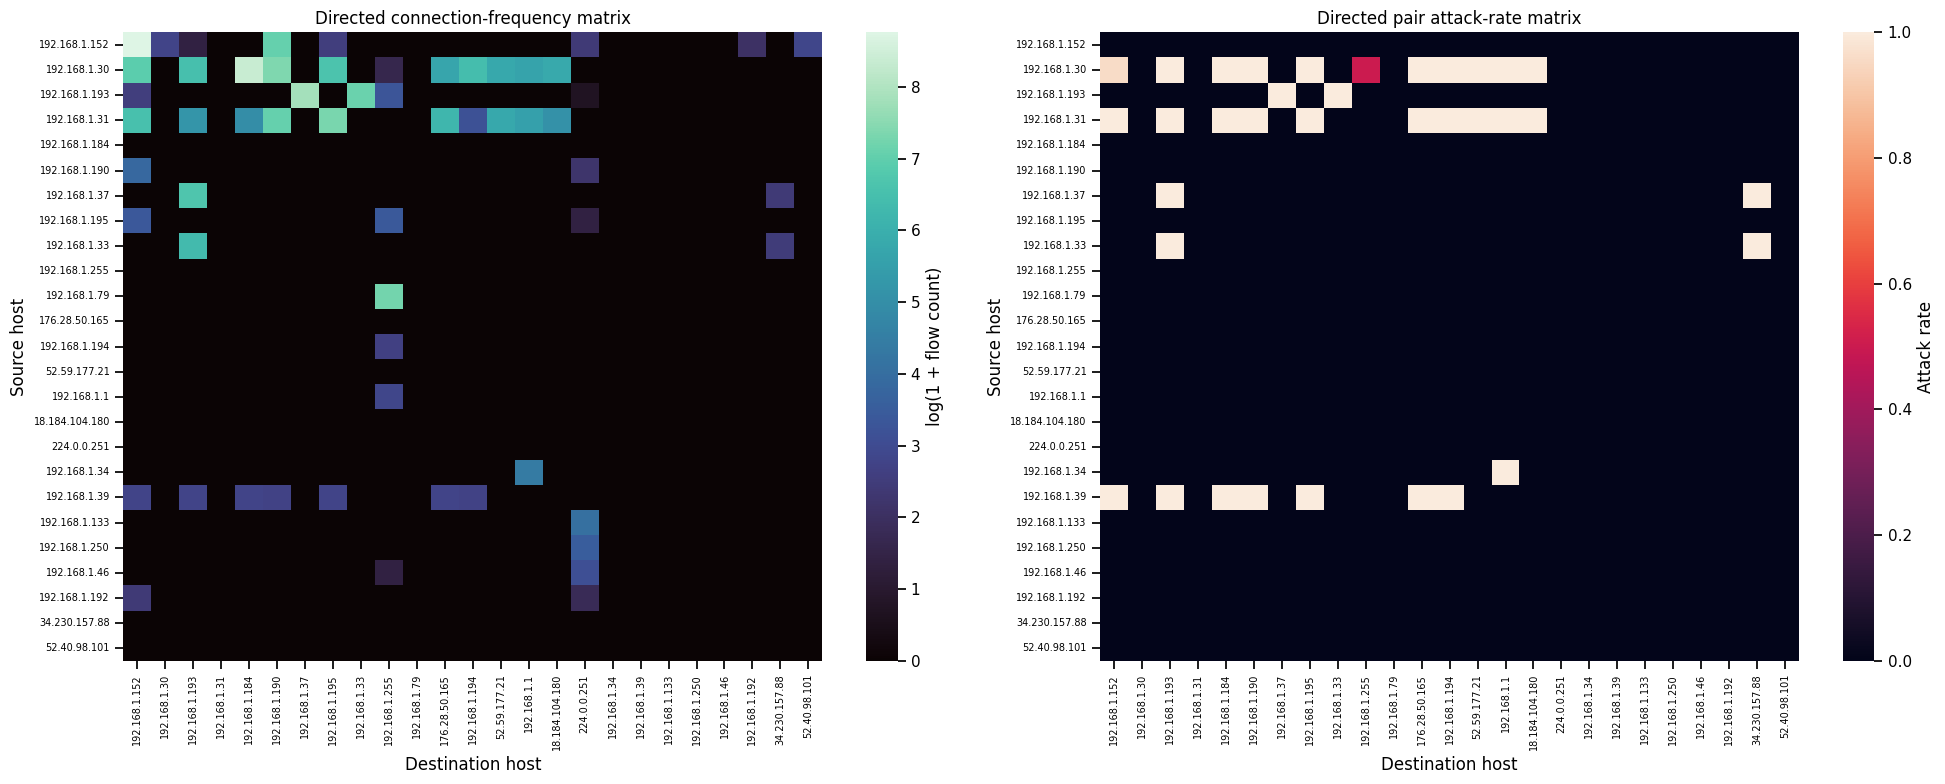

In [43]:
matrix_hosts=centrality_df.head(CFG.GRAPH_MATRIX_NODES).host.astype(str).tolist()
count_mat=(graph_view[graph_view.src_ip.astype(str).isin(matrix_hosts) & graph_view.dst_ip.astype(str).isin(matrix_hosts)]
           .pivot_table(index='src_ip',columns='dst_ip',values='label',aggfunc='size',fill_value=0)
           .reindex(index=matrix_hosts,columns=matrix_hosts,fill_value=0))
attack_mat=(graph_view[graph_view.src_ip.astype(str).isin(matrix_hosts) & graph_view.dst_ip.astype(str).isin(matrix_hosts)]
            .pivot_table(index='src_ip',columns='dst_ip',values='label',aggfunc='mean',fill_value=0)
            .reindex(index=matrix_hosts,columns=matrix_hosts,fill_value=0))
fig,ax=plt.subplots(1,2,figsize=(20,8))
sns.heatmap(np.log1p(count_mat),cmap='mako',ax=ax[0],cbar_kws={'label':'log(1 + flow count)'})
ax[0].set_title('Directed connection-frequency matrix');ax[0].set_xlabel('Destination host');ax[0].set_ylabel('Source host')
sns.heatmap(attack_mat,cmap='rocket',vmin=0,vmax=1,ax=ax[1],cbar_kws={'label':'Attack rate'})
ax[1].set_title('Directed pair attack-rate matrix');ax[1].set_xlabel('Destination host');ax[1].set_ylabel('Source host')
for a in ax:a.tick_params(axis='x',rotation=90,labelsize=7);a.tick_params(axis='y',labelsize=7)
plt.tight_layout();plt.show()

### 16.6 Ego Network of the Most Connected Host
A whole-network plot can hide local structure. The ego view below isolates the most active host and its strongest direct neighbours. This makes incoming/outgoing connections and attack-dominant relationships visually traceable.

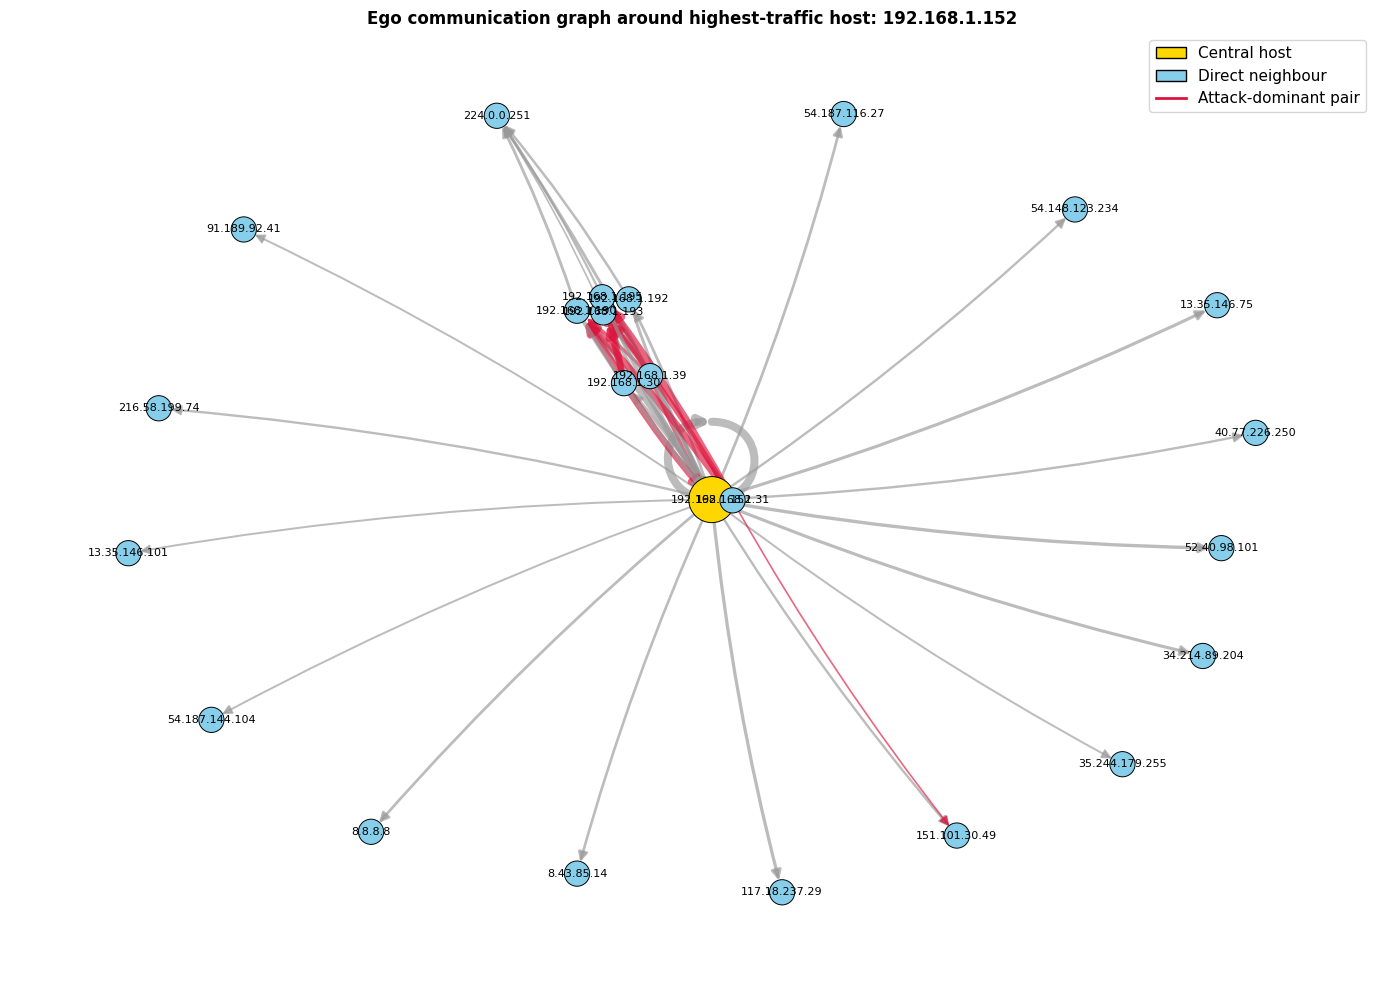

,src_ip,dst_ip,flow_count,attack_rate,dominant_attack,dominant_proto,dominant_service
0,192.168.1.152,192.168.1.152,6365,0.000000,normal,tcp,-
8,192.168.1.152,192.168.1.190,1174,0.000000,normal,udp,dns
9,192.168.1.30,192.168.1.152,1010,0.960396,dos,tcp,-
12,192.168.1.31,192.168.1.152,670,1.000000,password,tcp,http
28,192.168.1.190,192.168.1.152,44,0.000000,normal,tcp,-
31,192.168.1.195,192.168.1.152,28,0.000000,normal,tcp,-
36,192.168.1.152,52.40.98.101,16,0.000000,normal,tcp,-
38,192.168.1.39,192.168.1.152,15,1.000000,dos,tcp,-
42,192.168.1.152,192.168.1.30,15,0.000000,normal,tcp,-
45,192.168.1.152,117.18.237.29,14,0.000000,normal,tcp,-


In [44]:
hub=centrality_df.iloc[0].host
neigh=set(GA.predecessors(hub))|set(GA.successors(hub))
ranked_neigh=sorted(neigh,key=lambda n: weighted_degree.get(n,0),reverse=True)[:24]
EH=GA.subgraph([hub]+ranked_neigh).copy();epos=nx.spring_layout(EH,seed=CFG.SEED,k=.75,iterations=150)
edge_counts=np.array([d['flow_count'] for *_,d in EH.edges(data=True)],float)
ew=0.8+5*np.log1p(edge_counts)/max(np.log1p(edge_counts).max(),1e-9) if len(edge_counts) else []
ec=['crimson' if d['attack_rate']>=.5 else '0.6' for *_,d in EH.edges(data=True)]
ns=[1100 if n==hub else 330 for n in EH.nodes()];nc=['gold' if n==hub else 'skyblue' for n in EH.nodes()]
fig,ax=plt.subplots(figsize=(14,10));nx.draw_networkx_nodes(EH,epos,node_size=ns,node_color=nc,edgecolors='black',linewidths=.7,ax=ax)
nx.draw_networkx_edges(EH,epos,width=ew,edge_color=ec,alpha=.65,arrows=True,arrowsize=14,connectionstyle='arc3,rad=.04',ax=ax)
nx.draw_networkx_labels(EH,epos,font_size=8,ax=ax)
ax.legend(handles=[Patch(facecolor='gold',edgecolor='black',label='Central host'),Patch(facecolor='skyblue',edgecolor='black',label='Direct neighbour'),Line2D([0],[0],color='crimson',lw=2,label='Attack-dominant pair')])
ax.set_title(f'Ego communication graph around highest-traffic host: {hub}',fontweight='bold');ax.axis('off');plt.tight_layout();plt.show()

ego_rows=connection_table[(connection_table.src_ip.astype(str)==hub)|(connection_table.dst_ip.astype(str)==hub)].head(25)
display(ego_rows[['src_ip','dst_ip','flow_count','attack_rate','dominant_attack','dominant_proto','dominant_service']])

### 16.7 Temporal Graph Topology Across Event Snapshots
Because the processed network table has no wall-clock timestamp, graph time is represented by ordered fixed-count event snapshots. The next figure shows how node count, unique pair count, density, and attack rate evolve from snapshot to snapshot.

,snapshot,flow_edges,unique_nodes,unique_pairs,directed_density,attack_rate
0,0,2500,5,6,0.300000,1.0000
1,1,2500,10,9,0.100000,1.0000
2,2,2500,7,6,0.142857,1.0000
3,3,2500,13,18,0.115385,1.0000
4,4,2500,19,29,0.084795,1.0000
5,5,2500,14,16,0.087912,1.0000
6,6,2500,72,96,0.018779,0.1444
7,7,2500,21,28,0.066667,0.0000
8,8,2500,22,24,0.051948,0.0000
9,9,2500,38,44,0.031294,0.0648


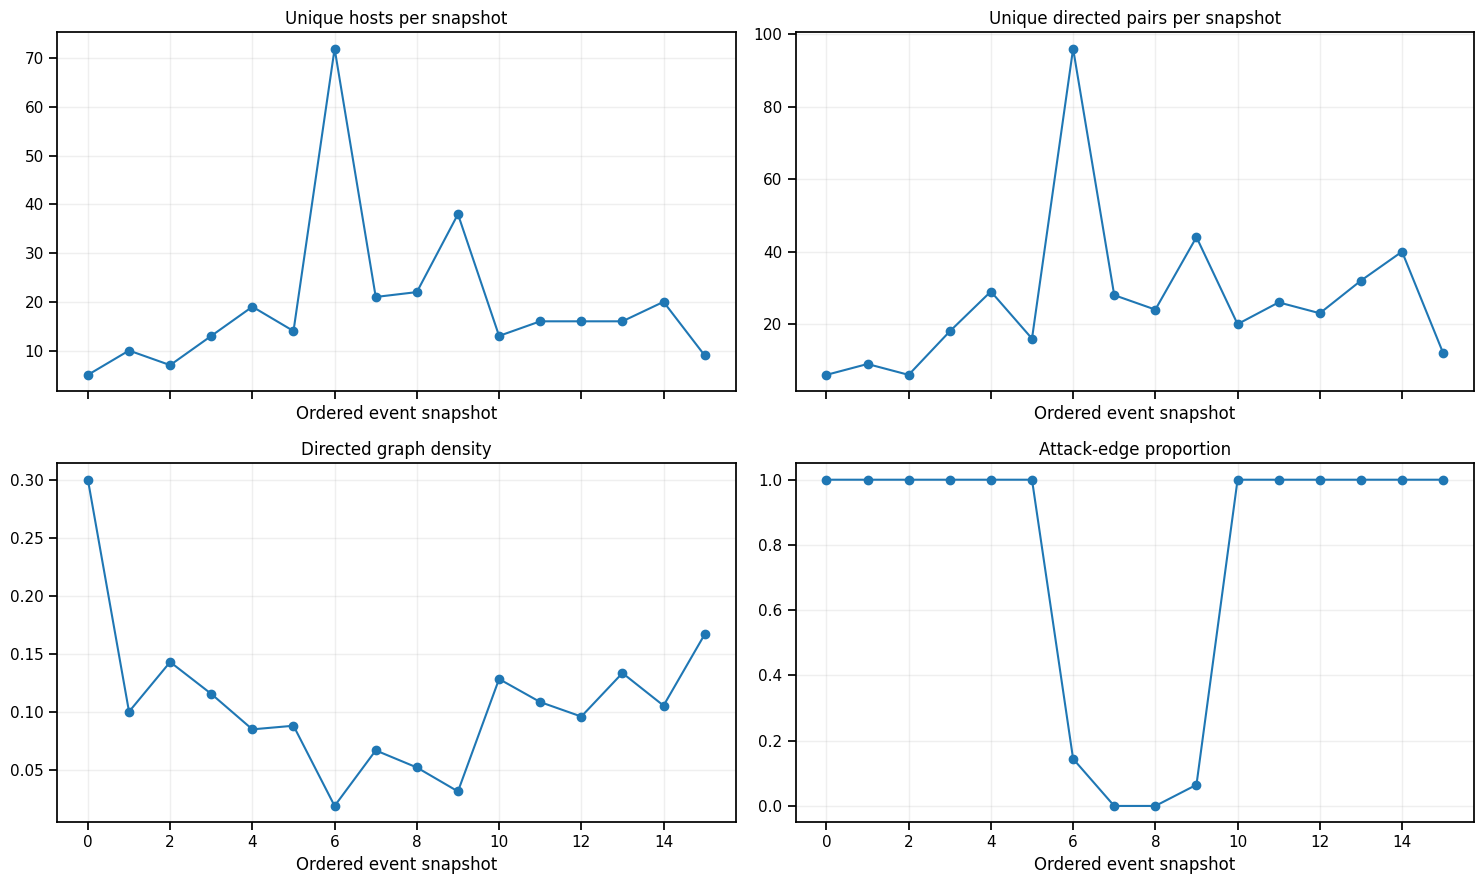

In [45]:
def snapshot_topology(df,w):
    rows=[]
    d=df.sort_values('_row_id').reset_index(drop=True)
    for sid,st in enumerate(range(0,len(d),w)):
        x=d.iloc[st:st+w]
        if len(x)==0:continue
        nodes=pd.unique(pd.concat([x.src_ip.astype(str),x.dst_ip.astype(str)],ignore_index=True))
        pairs=x[['src_ip','dst_ip']].drop_duplicates()
        n=len(nodes);e=len(pairs)
        rows.append({'snapshot':sid,'flow_edges':len(x),'unique_nodes':n,'unique_pairs':e,
                     'directed_density':e/max(n*(n-1),1),'attack_rate':x.label.mean()})
    return pd.DataFrame(rows)

topo=snapshot_topology(graph_tr,CFG.SNAPSHOT_EDGES)
display(topo.head(12))
fig,ax=plt.subplots(2,2,figsize=(15,9),sharex=True)
ax[0,0].plot(topo.snapshot,topo.unique_nodes,marker='o');ax[0,0].set_title('Unique hosts per snapshot')
ax[0,1].plot(topo.snapshot,topo.unique_pairs,marker='o');ax[0,1].set_title('Unique directed pairs per snapshot')
ax[1,0].plot(topo.snapshot,topo.directed_density,marker='o');ax[1,0].set_title('Directed graph density')
ax[1,1].plot(topo.snapshot,topo.attack_rate,marker='o');ax[1,1].set_title('Attack-edge proportion')
for a in ax.ravel():a.set_xlabel('Ordered event snapshot');a.grid(alpha=.2)
plt.tight_layout();plt.show()

## 16.8 Connection-Only Graph Baseline
Before training a neural GNN, we test whether **graph connection structure alone** contains predictive information. For every flow edge inside each event snapshot, the following label-free structural features are calculated:
- source out-flow count,
- destination in-flow count,
- repeated source→destination pair count,
- number of unique destinations contacted by the source,
- number of unique sources contacting the destination,
- source and destination total incident flow counts.

A Random Forest then predicts attack type from only these topology features. This is an important ablation: if it performs above chance, network connectivity itself carries intrusion signal even without packet/byte attributes.

In [46]:
TOPO_COLS=['src_out_flows','dst_in_flows','pair_flow_count','src_unique_dsts','dst_unique_srcs','src_incident_flows','dst_incident_flows']
def topology_edge_features(df,w):
    d=df.sort_values('_row_id').reset_index(drop=True).copy();parts=[]
    for st in range(0,len(d),w):
        x=d.iloc[st:st+w].copy()
        if len(x)==0:continue
        x['src_out_flows']=x.groupby('src_ip')['src_ip'].transform('size')
        x['dst_in_flows']=x.groupby('dst_ip')['dst_ip'].transform('size')
        x['pair_flow_count']=x.groupby(['src_ip','dst_ip'])['src_ip'].transform('size')
        x['src_unique_dsts']=x.groupby('src_ip')['dst_ip'].transform('nunique')
        x['dst_unique_srcs']=x.groupby('dst_ip')['src_ip'].transform('nunique')
        endpoint_counts=pd.concat([x.src_ip.astype(str),x.dst_ip.astype(str)]).value_counts()
        x['src_incident_flows']=x.src_ip.astype(str).map(endpoint_counts).astype(float)
        x['dst_incident_flows']=x.dst_ip.astype(str).map(endpoint_counts).astype(float)
        parts.append(x[TOPO_COLS])
    return pd.concat(parts,ignore_index=True).astype('float32')

Xt_tr=topology_edge_features(graph_tr,CFG.SNAPSHOT_EDGES);Xt_te=topology_edge_features(graph_te,CFG.SNAPSHOT_EDGES)
topo_rf=RandomForestClassifier(n_estimators=180,max_depth=18,min_samples_leaf=2,class_weight='balanced_subsample',n_jobs=-1,random_state=CFG.SEED)
t0=time.time();topo_rf.fit(Xt_tr,ygtr);topo_s=time.time()-t0
topo_pred=topo_rf.predict(Xt_te);topo_prob=topo_rf.predict_proba(Xt_te)
results['Topology-only RF']=evaluate(ygte,topo_pred,topo_prob,topo_s,size_mb(topo_rf))
print({k:round(v,4) for k,v in results['Topology-only RF'].items() if not k.startswith('_')})
display(pd.DataFrame({'feature':TOPO_COLS,'importance':topo_rf.feature_importances_}).sort_values('importance',ascending=False))

{'Accuracy': 0.402, 'Macro Precision': 0.3655, 'Macro Recall': 0.3958, 'Macro F1': 0.3121, 'Weighted F1': 0.3409, 'Binary ROC-AUC': np.float64(0.8378), 'Binary PR-AUC': np.float64(0.9404), 'False Positive Rate': np.float64(0.8111), 'Train Time (s)': 2.3635, 'Model Size (MB)': 5.2443}


,feature,importance
3,src_unique_dsts,0.238570
5,src_incident_flows,0.192967
0,src_out_flows,0.173428
6,dst_incident_flows,0.113786
2,pair_flow_count,0.098302
1,dst_in_flows,0.092282
4,dst_unique_srcs,0.090664


## 17. Track B — Temporal GraphSAGE + GRU
Architecture: node projection → two mean GraphSAGE layers → snapshot mean pooling → unidirectional GRU over snapshots → edge classifier using source, destination, absolute difference, temporal context, and edge attributes.

### 17.1 Paper-Style GNN Architecture and Message-Passing View
For snapshot \(G_t=(V_t,E_t)\), GraphSAGE updates each host representation by combining its own state with the mean state of its neighbours:

\[
h_v^{(k+1)}=\sigma\left(W_{self}h_v^{(k)}+W_{neigh}\,\mathrm{MEAN}_{u\in\mathcal{N}(v)}h_u^{(k)}\right)
\]

A graph-level snapshot context is then passed through a GRU:

\[
c_t=\mathrm{GRU}(\mathrm{MEAN}_{v\in V_t}h_v,c_{t-1})
\]

Finally, every original directed flow \(e=(u,v)\) is classified from source embedding, destination embedding, their difference, temporal context, and the flow attributes. The figure below is intentionally formatted like a methodology figure for a paper/report.

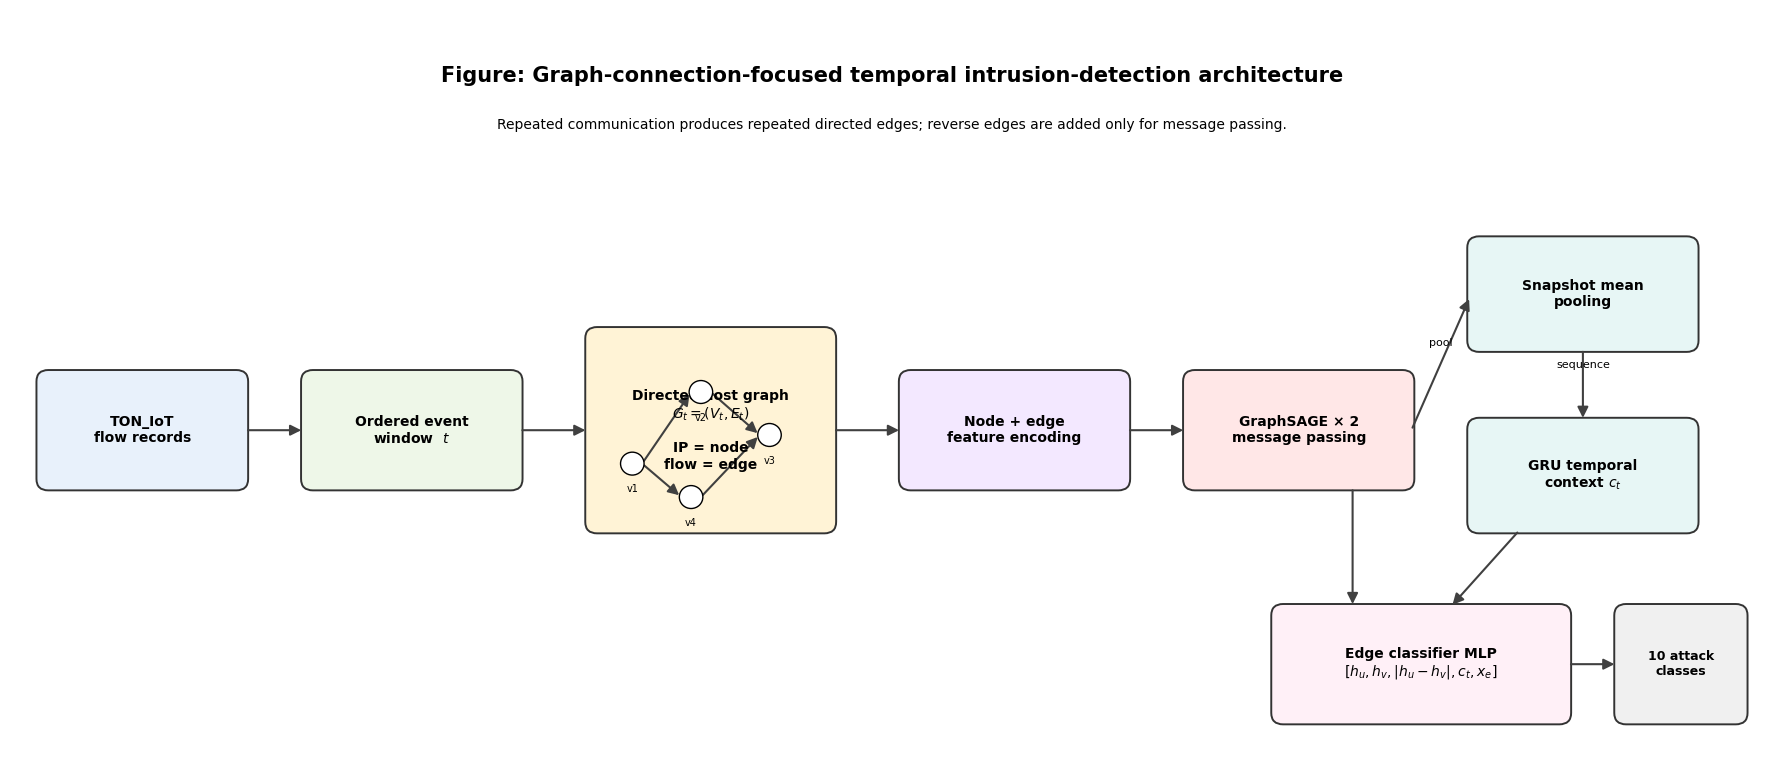

In [47]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
fig,ax=plt.subplots(figsize=(18,8));ax.set_xlim(0,18);ax.set_ylim(0,8);ax.axis('off')

def box(x,y,w,h,text,fc,fs=10):
    p=FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.03,rounding_size=.12',facecolor=fc,edgecolor='0.2',linewidth=1.4)
    ax.add_patch(p);ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=fs,fontweight='bold');return p

def arrow(x1,y1,x2,y2,label=None):
    a=FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=16,linewidth=1.5,color='0.25');ax.add_patch(a)
    if label:ax.text((x1+x2)/2,(y1+y2)/2+.18,label,ha='center',fontsize=8)

box(.3,3.0,2.1,1.2,'TON_IoT\nflow records','#e8f1fb')
box(3.0,3.0,2.2,1.2,'Ordered event\nwindow  $t$','#eef7e8')
box(5.9,2.55,2.5,2.1,'Directed host graph\n$G_t=(V_t,E_t)$\n\nIP = node\nflow = edge','#fff3d6')
box(9.1,3.0,2.3,1.2,'Node + edge\nfeature encoding','#f3e8ff')
box(12.0,3.0,2.3,1.2,'GraphSAGE × 2\nmessage passing','#ffe7e7')
box(14.9,4.45,2.3,1.15,'Snapshot mean\npooling','#e7f6f5')
box(14.9,2.55,2.3,1.15,'GRU temporal\ncontext $c_t$','#e7f6f5')
box(12.9,.55,3.0,1.2,'Edge classifier MLP\n$[h_u,h_v,|h_u-h_v|,c_t,x_e]$','#fff0f7')
box(16.4,.55,1.3,1.2,'10 attack\nclasses','#f0f0f0',9)
arrow(2.4,3.6,3.0,3.6);arrow(5.2,3.6,5.9,3.6);arrow(8.4,3.6,9.1,3.6);arrow(11.4,3.6,12.0,3.6)
arrow(14.3,3.6,14.9,5.0,'pool');arrow(16.05,4.45,16.05,3.7,'sequence');arrow(15.4,2.55,14.7,1.75)
arrow(13.7,3.0,13.7,1.75);arrow(15.9,1.15,16.4,1.15)

mini=[(6.35,3.25),(7.05,4.0),(7.75,3.55),(6.95,2.9)]
for j,(x,y) in enumerate(mini):
    ax.add_patch(Circle((x,y),.12,facecolor='white',edgecolor='black',zorder=5));ax.text(x,y-.3,f'v{j+1}',ha='center',fontsize=7)
for a,b in [(0,1),(1,2),(0,3),(3,2)]:
    arrow(mini[a][0]+.1,mini[a][1],mini[b][0]-.1,mini[b][1])
ax.text(9,7.25,'Figure: Graph-connection-focused temporal intrusion-detection architecture',ha='center',fontsize=15,fontweight='bold')
ax.text(9,6.75,'Repeated communication produces repeated directed edges; reverse edges are added only for message passing.',ha='center',fontsize=10)
plt.tight_layout();plt.show()

In [48]:
class MeanSAGE(nn.Module):
    def __init__(self,a,b):super().__init__();self.self_lin=nn.Linear(a,b);self.neigh_lin=nn.Linear(a,b,bias=False)
    def forward(self,x,ei):
        s,d=ei;ag=torch.zeros_like(x);ag.index_add_(0,d,x[s]);dg=torch.zeros((x.size(0),1),device=x.device,dtype=x.dtype);dg.index_add_(0,d,torch.ones((d.numel(),1),device=x.device,dtype=x.dtype));return self.self_lin(x)+self.neigh_lin(ag/dg.clamp_min(1.))
class TemporalGraphSAGE(nn.Module):
    def __init__(self,node_in,edge_in,classes,h=64,drop=.1):
        super().__init__();self.p=nn.Linear(node_in,h);self.s1=MeanSAGE(h,h);self.s2=MeanSAGE(h,h);self.gru=nn.GRU(h,h,batch_first=True);self.drop=drop;self.head=nn.Sequential(nn.Linear(h*4+edge_in,h*2),nn.ReLU(),nn.Dropout(drop),nn.Linear(h*2,classes))
    def enc(self,s):
        h=F.relu(self.p(s['node_x']));h=F.relu(self.s1(h,s['edge_index']));h=F.dropout(h,p=self.drop,training=self.training);return F.relu(self.s2(h,s['edge_index']))
    def forward_sequence(self,S):
        hs=[];pooled=[]
        for s in S:h=self.enc(s);hs.append(h);pooled.append(h.mean(0))
        ctx,_=self.gru(torch.stack(pooled)[None]);ctx=ctx[0];out=[]
        for t,(s,h) in enumerate(zip(S,hs)):
            a=h[s['flow_src']];b=h[s['flow_dst']];c=ctx[t][None].expand(a.size(0),-1);out.append(self.head(torch.cat([a,b,torch.abs(a-b),c,s['edge_attr']],1)))
        return torch.cat(out)

### 17.2 Tensor Shapes / Device Check

In [49]:
def move(S):return [{k:(v.to(DEVICE) if torch.is_tensor(v) else v) for k,v in s.items()} for s in S]
trD,vaD,teD=move(trS),move(vaS),move(teS);NODE_IN=trS[0]['node_x'].shape[1];EDGE_IN=trS[0]['edge_attr'].shape[1];NC=len(le.classes_)
print('node_in',NODE_IN,'edge_in',EDGE_IN,'classes',NC,'T_train',len(trD),'device',DEVICE)

node_in 52 edge_in 50 classes 10 T_train 16 device cuda


### 17.3 Weighted Loss, Early Stopping, Learning Curves
Square-root class weights reduce imbalance without allowing the rarest class to dominate optimisation.

Epoch 01 | loss=2.3091 | val_macro_f1=0.1479
Epoch 02 | loss=2.2405 | val_macro_f1=0.3029
Epoch 03 | loss=2.1806 | val_macro_f1=0.3103
Epoch 04 | loss=2.1112 | val_macro_f1=0.3037
Epoch 05 | loss=2.0212 | val_macro_f1=0.2879
Epoch 06 | loss=1.9345 | val_macro_f1=0.2883
Epoch 07 | loss=1.8169 | val_macro_f1=0.3125
Epoch 08 | loss=1.7107 | val_macro_f1=0.4676
Epoch 09 | loss=1.5965 | val_macro_f1=0.5553
Epoch 10 | loss=1.4601 | val_macro_f1=0.5919
Epoch 11 | loss=1.3177 | val_macro_f1=0.6483
Epoch 12 | loss=1.1860 | val_macro_f1=0.5880
Epoch 13 | loss=1.0602 | val_macro_f1=0.6784
Epoch 14 | loss=0.9355 | val_macro_f1=0.6221
Epoch 15 | loss=0.8088 | val_macro_f1=0.6668
Epoch 16 | loss=0.7135 | val_macro_f1=0.7140
Epoch 17 | loss=0.6369 | val_macro_f1=0.7188
Epoch 18 | loss=0.5940 | val_macro_f1=0.6772
Epoch 19 | loss=0.5036 | val_macro_f1=0.7860
Epoch 20 | loss=0.4519 | val_macro_f1=0.8020
Epoch 21 | loss=0.4010 | val_macro_f1=0.8047
Epoch 22 | loss=0.3544 | val_macro_f1=0.7113
Epoch 23 |

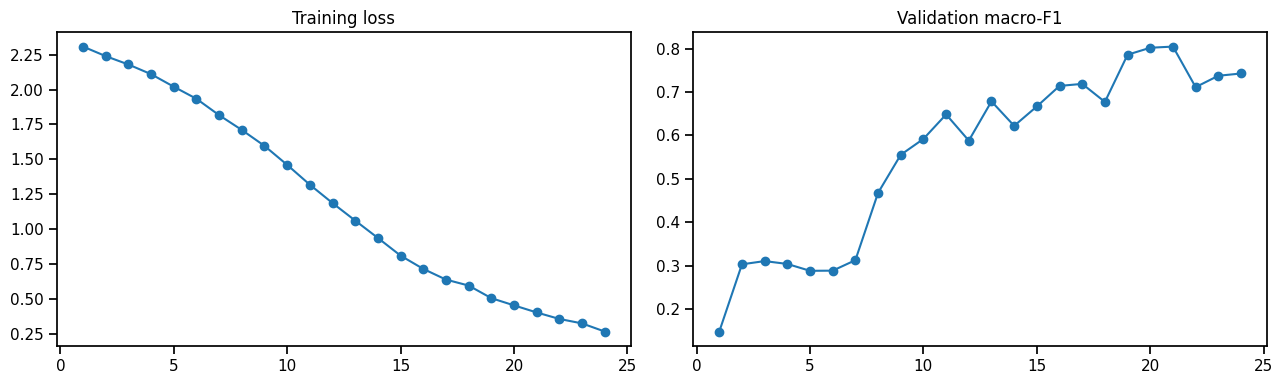

In [50]:
gw=np.sqrt(compute_class_weight('balanced',classes=np.arange(NC),y=ygtr));gw=np.minimum(gw,4.0);wt=torch.tensor(gw,dtype=torch.float32,device=DEVICE)
model=TemporalGraphSAGE(NODE_IN,EDGE_IN,NC,CFG.GNN_HIDDEN,CFG.GNN_DROPOUT).to(DEVICE);crit=nn.CrossEntropyLoss(weight=wt);opt=torch.optim.AdamW(model.parameters(),lr=CFG.GNN_LR,weight_decay=CFG.GNN_WEIGHT_DECAY)
try_y=torch.cat([s['y'] for s in trD]);vay=torch.cat([s['y'] for s in vaD]).cpu().numpy();bestf=-1;beststate=None;bad=0;hist=[];start=time.time()
for e in range(1,CFG.GNN_EPOCHS+1):
    model.train();opt.zero_grad();z=model.forward_sequence(trD);loss=crit(z,try_y);loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),5.);opt.step()
    model.eval()
    with torch.no_grad():vp=model.forward_sequence(vaD).argmax(1).cpu().numpy()
    vf=f1_score(vay,vp,average='macro',zero_division=0);hist.append({'epoch':e,'loss':float(loss.item()),'val_macro_f1':vf});print(f'Epoch {e:02d} | loss={loss.item():.4f} | val_macro_f1={vf:.4f}')
    if vf>bestf+1e-4:bestf=vf;beststate={k:v.detach().cpu().clone() for k,v in model.state_dict().items()};bad=0
    else:
        bad+=1
        if bad>=CFG.GNN_PATIENCE:print('Early stopping');break
gnn_time=time.time()-start;model.load_state_dict(beststate);model.to(DEVICE);print('Best val macro-F1',round(bestf,4),'| train seconds',round(gnn_time,2))
h=pd.DataFrame(hist);fig,ax=plt.subplots(1,2,figsize=(13,4));ax[0].plot(h.epoch,h.loss,marker='o');ax[0].set_title('Training loss');ax[1].plot(h.epoch,h.val_macro_f1,marker='o');ax[1].set_title('Validation macro-F1');plt.tight_layout();plt.show()

### 17.4 GNN Test Evaluation on the Same Test Rows as Track A

In [51]:
model.eval()
with torch.no_grad():z=model.forward_sequence(teD);gprob=torch.softmax(z,1).cpu().numpy();gpred=z.argmax(1).cpu().numpy()
gmb=sum(p.numel()*p.element_size() for p in model.parameters())/(1024**2);results['Temporal GraphSAGE-GRU']=evaluate(ygte,gpred,gprob,gnn_time,gmb);print({k:round(v,4) for k,v in results['Temporal GraphSAGE-GRU'].items() if not k.startswith('_')})

{'Accuracy': 0.7798, 'Macro Precision': 0.7314, 'Macro Recall': 0.7345, 'Macro F1': 0.719, 'Weighted F1': 0.7806, 'Binary ROC-AUC': np.float64(0.922), 'Binary PR-AUC': np.float64(0.9774), 'False Positive Rate': np.float64(0.4105), 'Train Time (s)': 3.4266, 'Model Size (MB)': 0.326}


## 18. Comparative Results — Identical Edge-Level Test Set

This table now compares **seven tabular baselines**, a **connection-only topology baseline**, and the **Temporal GraphSAGE-GRU** on the same edge-level test rows. The topology-only result is especially important because it isolates the predictive value of graph connections from packet/byte attributes.

,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Binary ROC-AUC,Binary PR-AUC,False Positive Rate,Train Time (s),Model Size (MB)
Random Forest,0.9531,0.9182,0.8909,0.8995,0.9508,0.9957,0.9988,0.0134,5.6842,33.3566
Extra Trees,0.8855,0.8777,0.8603,0.8557,0.8877,0.9922,0.9978,0.3057,3.0395,74.3486
Decision Tree,0.8620,0.7974,0.7979,0.7793,0.8487,0.9713,0.9829,0.0552,0.5355,0.1573
Temporal GraphSAGE-GRU,0.7798,0.7314,0.7345,0.7190,0.7806,0.9220,0.9774,0.4105,3.4266,0.3260
Logistic Regression,0.6572,0.7147,0.7640,0.6552,0.6224,0.2917,0.7275,0.9430,28.5620,0.0046
SGD Log-Loss,0.5823,0.6269,0.6848,0.5637,0.5367,0.1124,0.5857,0.9423,2.9004,0.0030
Gaussian Naive Bayes,0.5976,0.5636,0.5809,0.4866,0.5831,0.9754,0.9850,0.0999,0.0328,0.0084
Topology-only RF,0.4020,0.3655,0.3958,0.3121,0.3409,0.8378,0.9404,0.8111,2.3635,5.2443
Dummy Most-Frequent,0.2369,0.0237,0.1000,0.0383,0.0908,0.5000,0.7631,0.0000,0.0029,0.0006


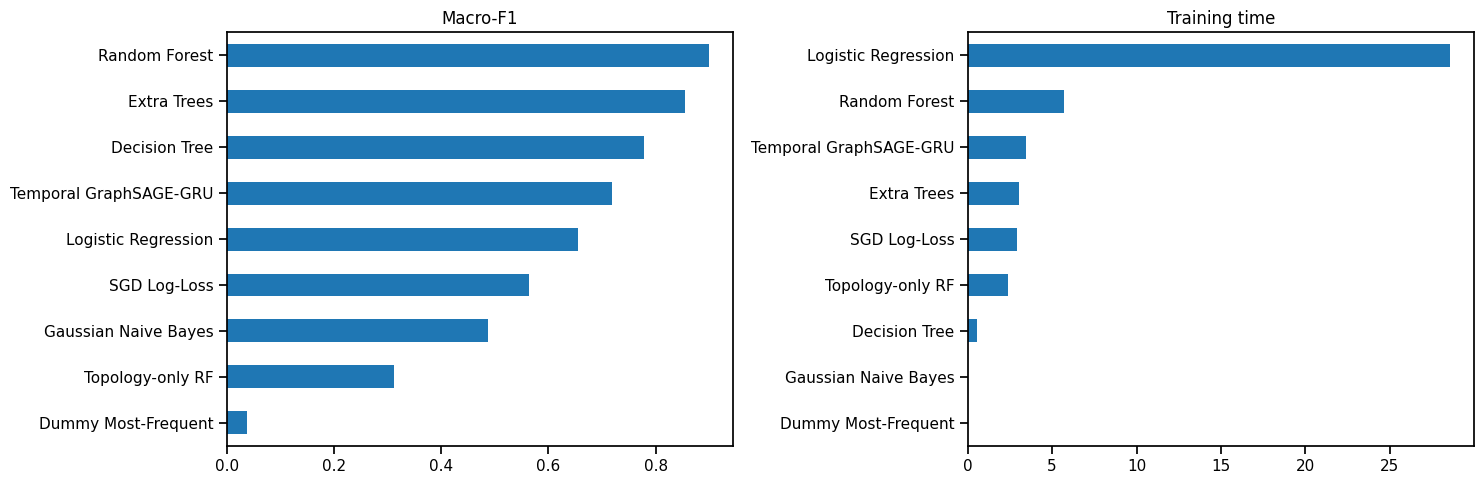

In [52]:
cols=['Accuracy','Macro Precision','Macro Recall','Macro F1','Weighted F1','Binary ROC-AUC','Binary PR-AUC','False Positive Rate','Train Time (s)','Model Size (MB)']
rt=pd.DataFrame({n:{k:v for k,v in r.items() if k in cols} for n,r in results.items()}).T.sort_values('Macro F1',ascending=False);display(rt.round(4))
fig,ax=plt.subplots(1,2,figsize=(15,5));rt['Macro F1'].sort_values().plot(kind='barh',ax=ax[0],title='Macro-F1');rt['Train Time (s)'].sort_values().plot(kind='barh',ax=ax[1],title='Training time');plt.tight_layout();plt.show()

### 18.1 Binary ROC and Precision–Recall Curves

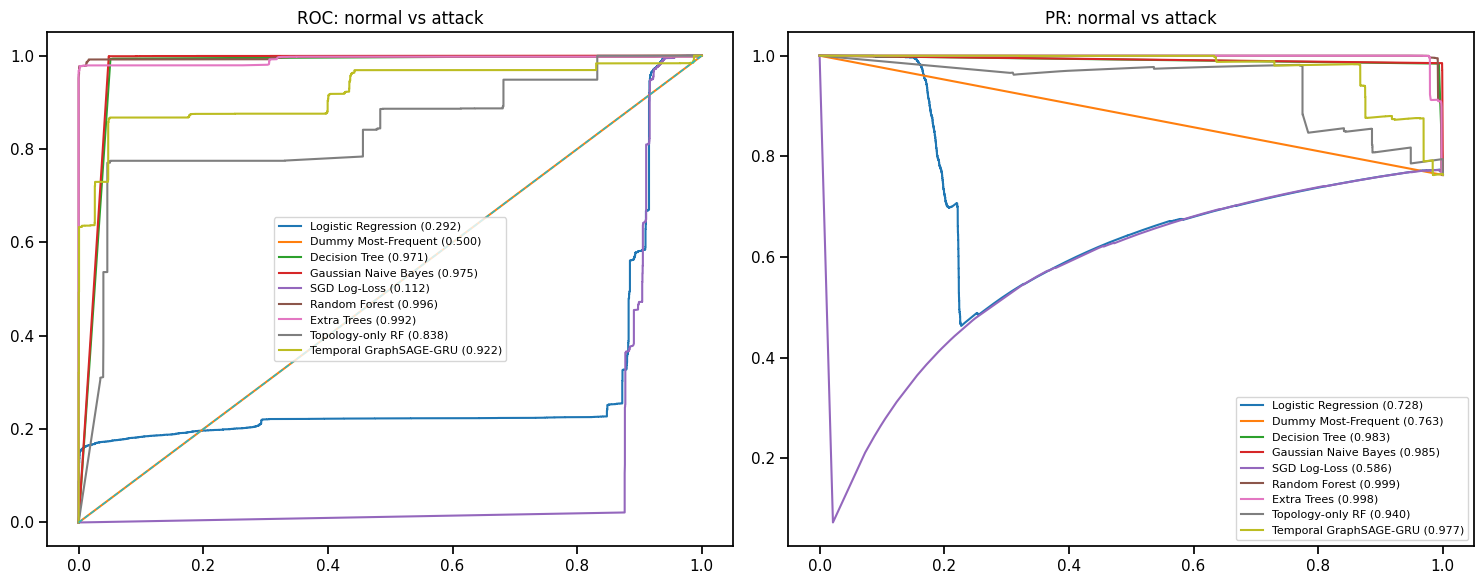

In [53]:
ybin=(ygte!=NORMAL_ID).astype(int);fig,ax=plt.subplots(1,2,figsize=(15,6))
for n,r in results.items():
    p=1-r['_proba'][:,NORMAL_ID];fpr,tpr,_=roc_curve(ybin,p);pr,re,_=precision_recall_curve(ybin,p);ax[0].plot(fpr,tpr,label=f"{n} ({roc_auc_score(ybin,p):.3f})");ax[1].plot(re,pr,label=f"{n} ({average_precision_score(ybin,p):.3f})")
ax[0].plot([0,1],[0,1],'--',linewidth=1);ax[0].set_title('ROC: normal vs attack');ax[1].set_title('PR: normal vs attack');ax[0].legend(fontsize=8);ax[1].legend(fontsize=8);plt.tight_layout();plt.show()

### 18.2 Multiclass Confusion Matrices

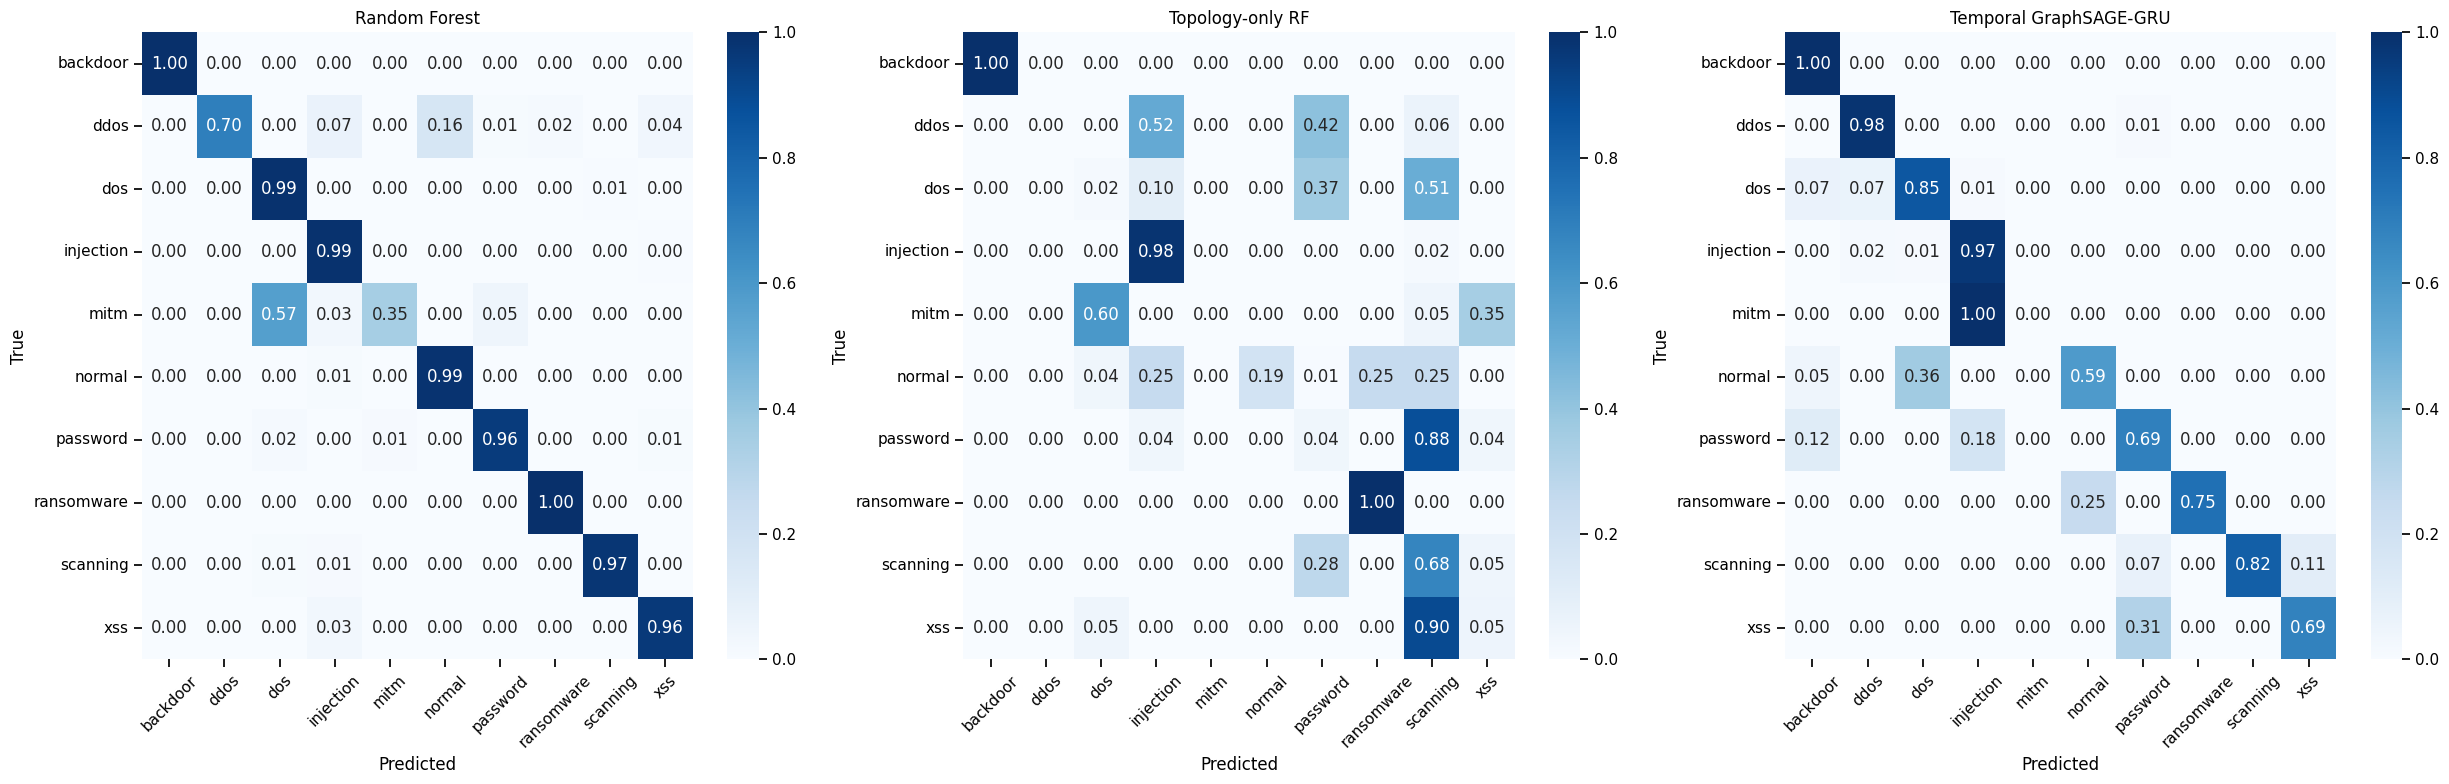

In [54]:
cm_models=['Random Forest','Topology-only RF','Temporal GraphSAGE-GRU']
fig,ax=plt.subplots(1,3,figsize=(25,8))
for a,n in zip(ax,cm_models):
    cm=confusion_matrix(ygte,results[n]['_pred'],labels=np.arange(NC),normalize='true')
    sns.heatmap(cm,annot=True,fmt='.2f',cmap='Blues',ax=a,xticklabels=le.classes_,yticklabels=le.classes_)
    a.set_title(n);a.tick_params(axis='x',rotation=45);a.set_xlabel('Predicted');a.set_ylabel('True')
plt.tight_layout();plt.show()

## 19. Statistical Model Comparison — Exact McNemar Test
**H₀:** Random Forest and Temporal GraphSAGE-GRU have equal marginal error rates on the paired test observations.

In [55]:
rc=results['Random Forest']['_pred']==ygte;gc=results['Temporal GraphSAGE-GRU']['_pred']==ygte;b=int(np.sum(rc&~gc));c=int(np.sum(~rc&gc));pm=binomtest(min(b,c),n=b+c,p=.5,alternative='two-sided').pvalue if b+c else 1.;print('RF correct/GNN wrong:',b,'| RF wrong/GNN correct:',c,'| p=',pm);print('Decision:','Reject H0' if pm<.05 else 'Fail to reject H0')

RF correct/GNN wrong: 2495 | RF wrong/GNN correct: 416 | p= 0.0
Decision: Reject H0


## 20. Error Analysis: Per-Class Recall + Operational FP/FN

model,Decision Tree,Dummy Most-Frequent,Extra Trees,Gaussian Naive Bayes,Logistic Regression,Random Forest,SGD Log-Loss,Temporal GraphSAGE-GRU,Topology-only RF
class,,,,,,,,,
backdoor,1.000,0.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
ddos,0.603,0.0,0.717,0.579,0.601,0.697,0.598,0.982,0.000
dos,0.240,0.0,0.989,0.939,0.963,0.989,0.944,0.850,0.018
injection,0.990,0.0,0.991,0.150,0.912,0.992,0.313,0.970,0.984
mitm,0.317,0.0,0.317,0.900,0.833,0.350,0.833,0.000,0.000
normal,0.945,1.0,0.694,0.900,0.057,0.987,0.058,0.590,0.189
password,0.961,0.0,0.960,0.728,0.802,0.957,0.785,0.695,0.040
ransomware,1.000,0.0,1.000,0.991,0.887,1.000,0.836,0.753,1.000
scanning,0.974,0.0,0.974,0.172,0.806,0.974,0.788,0.819,0.675


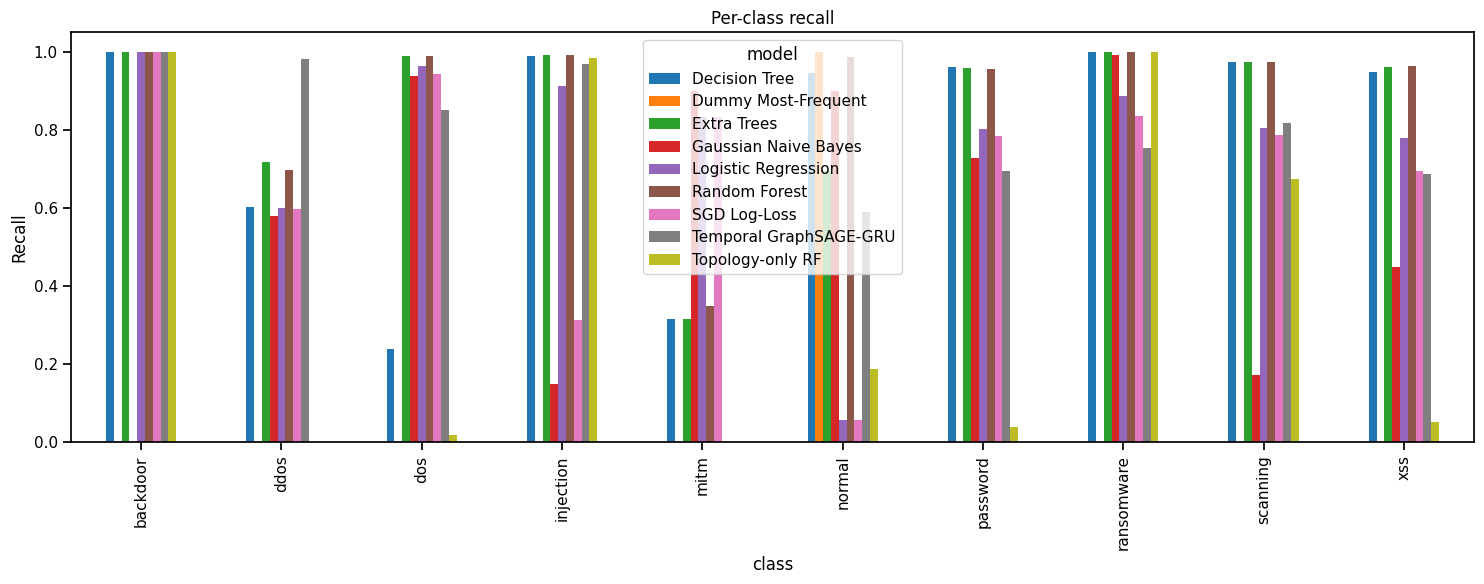

,TN,FP,FN,TP,FPR,FNR
model,,,,,,
Logistic Regression,162,2681,49,9108,0.9430,0.0054
Dummy Most-Frequent,2843,0,9157,0,0.0000,1.0000
Decision Tree,2686,157,58,9099,0.0552,0.0063
Gaussian Naive Bayes,2559,284,8,9149,0.0999,0.0009
SGD Log-Loss,164,2679,84,9073,0.9423,0.0092
Random Forest,2805,38,192,8965,0.0134,0.0210
Extra Trees,1974,869,162,8995,0.3057,0.0177
Topology-only RF,537,2306,1,9156,0.8111,0.0001
Temporal GraphSAGE-GRU,1676,1167,282,8875,0.4105,0.0308


In [56]:
r=[]
for n,x in results.items():
    vals=recall_score(ygte,x['_pred'],average=None,labels=np.arange(NC),zero_division=0)
    for cls,v in zip(le.classes_,vals):r.append({'model':n,'class':cls,'recall':v})
pv=pd.DataFrame(r).pivot(index='class',columns='model',values='recall');display(pv.round(3));pv.plot(kind='bar',figsize=(15,6));plt.ylabel('Recall');plt.title('Per-class recall');plt.tight_layout();plt.show()
er=[]
for n,x in results.items():
    pb=(x['_pred']!=NORMAL_ID).astype(int);tn,fp,fn,tp=confusion_matrix(ybin,pb,labels=[0,1]).ravel();er.append({'model':n,'TN':tn,'FP':fp,'FN':fn,'TP':tp,'FPR':fp/max(fp+tn,1),'FNR':fn/max(fn+tp,1)})
display(pd.DataFrame(er).set_index('model').round(4))

### 20.1 Misclassified Flow Examples

In [57]:
def show_errors(name,n=12):
    p=results[name]['_pred'];bad=np.where(p!=ygte)[0]
    if not len(bad):print('No errors');return
    idx=bad[:n];cols=['_row_id','src_ip','src_port','dst_ip','dst_port','proto','service','conn_state','type','label'];o=graph_te.iloc[idx][cols].copy();o['predicted_type']=le.inverse_transform(p[idx]);display(o)
print('Random Forest errors');show_errors('Random Forest');print('GNN errors');show_errors('Temporal GraphSAGE-GRU')

Random Forest errors


,_row_id,src_ip,src_port,dst_ip,dst_port,proto,service,conn_state,type,label,predicted_type
1175,36037,192.168.1.30,56854,192.168.1.194,80,tcp,-,S0,ddos,1,xss
1176,36038,192.168.1.30,56856,192.168.1.194,80,tcp,-,S0,ddos,1,xss
1177,36039,192.168.1.30,56858,192.168.1.194,80,tcp,-,S0,ddos,1,xss
1179,36041,192.168.1.30,60197,192.168.1.1,53,udp,dns,S0,ddos,1,normal
1180,36042,192.168.1.30,60824,192.168.1.1,53,udp,dns,SF,ddos,1,normal
1181,36043,192.168.1.31,35232,192.168.1.190,80,tcp,-,S1,ddos,1,injection
1183,36045,192.168.1.31,35246,192.168.1.190,80,tcp,-,S1,ddos,1,injection
1185,36047,192.168.1.31,35270,192.168.1.190,80,tcp,-,OTH,ddos,1,xss
1186,36048,192.168.1.31,35274,192.168.1.190,80,tcp,-,OTH,ddos,1,xss
1197,36059,192.168.1.31,35324,192.168.1.190,80,tcp,-,S1,ddos,1,injection


GNN errors


,_row_id,src_ip,src_port,dst_ip,dst_port,proto,service,conn_state,type,label,predicted_type
1259,36121,192.168.1.30,41062,192.168.1.195,80,tcp,http,SF,ddos,1,password
1260,36122,192.168.1.30,41064,192.168.1.195,80,tcp,http,SF,ddos,1,password
1264,36126,192.168.1.30,41076,192.168.1.195,80,tcp,http,SF,ddos,1,password
1265,36127,192.168.1.30,41078,192.168.1.195,80,tcp,http,SF,ddos,1,password
1449,36311,192.168.1.30,41082,192.168.1.195,80,tcp,http,SF,ddos,1,password
1450,36312,192.168.1.30,41092,192.168.1.195,80,tcp,http,SF,ddos,1,password
1451,36313,192.168.1.30,41094,192.168.1.195,80,tcp,http,SF,ddos,1,password
1593,36455,192.168.1.30,41152,192.168.1.195,80,tcp,http,SF,ddos,1,password
1654,36516,192.168.1.38,1,52.59.177.21,1,tcp,-,S0,ddos,1,dos
1704,36566,192.168.1.30,41204,192.168.1.195,80,tcp,http,SF,ddos,1,password


## 21. Discussion
- Tree ensembles can be extremely strong on TON_IoT because flow attributes themselves encode distinctive attack behaviour.
- The GNN tests a different hypothesis: host-to-host topology and snapshot evolution add information beyond individual flows.
- If the GNN underperforms, that is still a valid result when supported by identical splits, metrics, runtime, and the McNemar test.
- Inspect per-class recall: structural attacks such as scanning/DDoS may benefit differently from relational modelling than payload/service-driven attacks.
- A tiny accuracy gain is not automatically valuable if model size, training time, or FPR is much worse.

### Graph-Connection Interpretation
The connection analysis should be read together with the classifier metrics. High-frequency directed pairs, asymmetric source/destination roles, and changing snapshot density show that the data contains relational structure that is invisible to a purely row-wise model. The **Topology-only RF** acts as a direct ablation of that structure. If it performs meaningfully above a naive baseline, graph connectivity is informative; if packet-feature ensembles still dominate, the correct conclusion is that topology adds context but the current graph/GNN formulation does not yet exploit it as efficiently as tree ensembles.

The weighted directed graph, ego network, connection matrices, snapshot topology plots, and edge-index audit are therefore central evidence rather than decorative figures.

## 22. Limitations / System Failsafes
1. The processed network CSV lacks timestamp/capture ID; event-count snapshots are not wall-clock windows.
2. Ordered-within-scenario splitting is safer than random flow shuffling but weaker than true capture-wise holdout.
3. Preprocessing is fitted only on training data; validation is used for tuning; test is held out.
4. Snapshot node IDs are local and there is no learned global host-ID embedding, reducing identity leakage.
5. Class weights are used instead of graph-distorting SMOTE/edge duplication.
6. `FAST_MODE` preserves all analytical sections while capping runtime.
7. All metrics/figures are computed by code; no result is manually inserted.

## 23. Conclusion and Future Work
### Conclusion
This notebook implements the complete dual-track AIML505 pipeline on TON_IoT: statistical characterization, leakage-aware preprocessing, classical baselines, dynamic graph construction, Temporal GraphSAGE-GRU training, identical-test-set comparison, hypothesis testing, and error analysis.

### Future work
- Reconstruct true time windows using raw network timestamps/capture IDs.
- Build a heterogeneous graph with hosts, services, ports, gateways, sensors, and OS events.
- Compare GAT, TGAT/TGN, DySAT, or other temporal GNNs.
- Use leave-one-capture/attack-scenario-out validation.
- Add probability calibration and operational threshold optimisation for low-FPR deployment.

### Graph-focused extension completed
This version adds a direct audit trail from `src_ip → dst_ip` rows to graph indices, weighted directed connection views that preserve repeated communication, local ego-network analysis, connection/attack matrices, topology evolution across snapshots, a topology-only structural baseline, and a paper-style Temporal GraphSAGE-GRU architecture figure. These additions make the **graph construction and connection logic** the central methodological contribution of the notebook.

## 24. Reproducibility and Kaggle Submission Checklist
- [x] Seeds fixed and versions printed.
- [x] Dataset attached via Kaggle input search; no dataset slug hard-coded.
- [x] No incompatible modality concatenation.
- [x] Statistical analysis exists as a dedicated section.
- [x] No random-flow split.
- [x] Train-only fitted preprocessing.
- [x] Validation-only model selection/early stopping.
- [x] Formal graph definition, adjacency, features, snapshots, and visualisation.
- [x] Track A + Track B implemented.
- [x] Accuracy, macro precision/recall/F1, ROC-AUC, PR-AUC, FPR, confusion matrices, time, size.
- [x] Paired hypothesis test and error analysis.

**Kaggle:** Add Data → optional GPU → **Save Version → Save & Run All (Commit)** → verify every output → submit committed URL + exported `.ipynb`.

## 25. Viva-Ready Shape and Design Notes
- `edge_attr`: `[E, F_edge]`
- `flow_src`, `flow_dst`: `[E]`
- `edge_index`: `[2, 2E]` because reverse message-passing edges are added
- `node_x`: `[N, 2 + F_edge]`
- GraphSAGE output: `[N, H]`
- pooled snapshot: `[H]`
- GRU input: `[1, T, H]`
- temporal context: `[T, H]`
- final logits: `[E_total, C]`, with `C=10`

**Likely questions:** Why no random split? Why are IPs nodes rather than tabular features? Why reverse edges for message passing? Why macro-F1? Why class weights instead of SMOTE? What changes when snapshot size doubles? Why is event-order not equivalent to clock time? Why can a Random Forest legitimately beat a GNN?

## 26. References
1. Alsaedi, A., Moustafa, N., Tari, Z., Mahmood, A., & Anwar, A. (2020). *TON_IoT telemetry dataset: A new generation dataset of IoT and IIoT for data-driven intrusion detection systems*. IEEE Access, 8, 165130–165150.
2. Moustafa, N. (2021). *A new distributed architecture for evaluating AI-based security systems at the edge: Network TON_IoT datasets*. Sustainable Cities and Society, 72, 102994.
3. Booij, T. M., Chiscop, I., Meeuwissen, E., Moustafa, N., & den Hartog, F. T. H. (2021). *ToN IoT: The role of heterogeneity and the need for standardization of features and attack types in IoT network intrusion datasets*. IEEE Internet of Things Journal.
4. Hamilton, W. L., Ying, R., & Leskovec, J. (2017). *Inductive Representation Learning on Large Graphs*. NeurIPS.
5. Veličković, P., et al. (2018). *Graph Attention Networks*. ICLR.
6. Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. ICLR.
7. UNSW Canberra, *The TON_IoT Datasets* (official project page).
8. Xu, K., Hu, W., Leskovec, J., & Jegelka, S. (2019). *How Powerful are Graph Neural Networks?* ICLR.
9. Cho, K., et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation*. EMNLP. (GRU architecture reference.)